## Evaluation Strategy

### Why ROC-AUC and F1 and not accuracy

The dataset has a **78 / 22 class imbalance** (18,691 non-default vs 5,309 default in the raw training set).  
A naive classifier that predicts *no default* for every observation would achieve **~78% accuracy** while providing zero predictive value.  
Géron (2019, Ch. 3) notes that accuracy can be misleading for imbalanced datasets.

| Metric | Why it is appropriate here |
|---|---|
| **ROC-AUC** | Measures ranking ability across **all** decision thresholds: important for credit risk where the cut-off is a business decision, not fixed at 0.5. Unaffected by class imbalance in its calculation. |
| **F1 (minority class)** | Harmonic mean of precision and recall for class 1 (defaulters). Penalises both missed defaults (low recall) and false alarms (low precision). Directly reflects the cost trade-off a lender faces. |
| ~~Accuracy~~ | Misleading as it is dominated by the majority class. Excluded as a primary metric. |


### What the EDA tells us about expected model behaviour

Key signals identified in `01_EDA.ipynb` and `02_preprocessing.ipynb` that inform model selection:

- **PAY_0 is among the strongest predictors**: default rate sits at 13% at repayment status 0, jumps sharply to 34% at status 1, and rises to 69% at status 2 and 77%  status 3. This non-linear step-change favours **tree-based models** that can split on ordinal thresholds. (MAX_DLQ — derived from all six PAY columns, ultimately ranked highest by XGBoost gain, with PAY_0 second.)
- **BILL_AMT1–6 are highly collinear** (r = 0.80–0.95): raw bill amounts largely track each other month-to-month. `TOTAL_BILL` and `BILL_TREND` were engineered to compress this redundancy.
- **AVG_PAY_STATUS and MAX_DLQ are correlated** (r = 0.806, flagged in  preprocessing): tree ensembles handle this naturally via feature subsampling;   logistic regression may show inflated variance on these features.
- **LIMIT_BAL is inversely associated with default**: clients with higher credit  limits default less (median NT$150,000 vs NT$90,000 for defaulters --> a 67% gap).  Captured directly as a scaled feature and implicitly through `UTIL_RATE`.
- **EDUCATION and MARRIAGE** show modest but real default rate differences across  categories,  one-hot encoded with `drop='first'` to avoid multicollinearity in linear models.


### Candidate models

Following Géron's shortlisting principle (Ch. 2): *'train many quick-and-dirty models from different categories, then shortlist the most promising ones'*.

| Model | Category | Rationale |
|---|---|---|
| **Logistic Regression** | Linear | Interpretable baseline; exposes whether the feature engineering alone is sufficient for a linear separator. L2 penalty handles multicollinearity. |
| **Random Forest** | Bagging ensemble | Robust to multicollinearity via random feature subsets; handles non-linear PAY status steps naturally; low variance via averaging  |
| **Gradient Boosting (sklearn)** | Boosting ensemble | Sequentially corrects residuals; often outperforms RF on tabular data when well-calibrated. |
| **XGBoost** | Modern boosting | Regularised gradient boosting with built-in L1/L2; state-of-the-art on structured tabular problems; required as a 'modern approach' required by the assessment brief. |

All four models are trained and evaluated twice: once on `X_tr_res` / `y_tr_res` (SMOTE, 67/33, 23,830 rows) and once on `X_tr_us` / `y_tr_us` (random undersampling, 67/33, 13,539 rows). Both experiments evaluate on the same `X_val` / `y_val` (natural 22% default rate). The sampling strategy that produces better ROC-AUC and F1 on validation is carried forward to fine-tuning.

Imports:

In [1]:
import os
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import randint

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve,
)

from sklearn.calibration import calibration_curve

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier

import tensorflow as tf
import xgboost
import sklearn

from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score


In [2]:
artefact_dir = os.path.join(os.path.dirname(os.getcwd()), "data", "processed", "artefacts")

X_tr_res    = pd.read_csv(os.path.join(artefact_dir, "X_tr_res.csv"))
y_tr_res    = pd.read_csv(os.path.join(artefact_dir, "y_tr_res.csv")).squeeze()
X_val       = pd.read_csv(os.path.join(artefact_dir, "X_val.csv"))
y_val       = pd.read_csv(os.path.join(artefact_dir, "y_val.csv")).squeeze()
X_test_proc = pd.read_csv(os.path.join(artefact_dir, "X_test_proc.csv"))
y_test      = pd.read_csv(os.path.join(artefact_dir, "y_test.csv")).squeeze()
X_tr_us     = pd.read_csv(os.path.join(artefact_dir, "X_tr_us.csv"))
y_tr_us     = pd.read_csv(os.path.join(artefact_dir, "y_tr_us.csv")).squeeze()

print("Shapes loaded:")
print(f"  X_tr_res    : {X_tr_res.shape}    y_tr_res    : {y_tr_res.shape}")
print(f"  X_val       : {X_val.shape}       y_val       : {y_val.shape}")
print(f"  X_test_proc : {X_test_proc.shape}    y_test      : {y_test.shape}")
print(f"  X_tr_us     : {X_tr_us.shape}     y_tr_us     : {y_tr_us.shape}")
print()

# Confirm column alignment across all splits
cols_match_val  = list(X_tr_res.columns) == list(X_val.columns)
cols_match_test = list(X_tr_res.columns) == list(X_test_proc.columns)
sym = lambda ok: "✅" if ok else "❌"
print(f"{sym(cols_match_val)}  X_tr_res columns match X_val       : {cols_match_val}")
print(f"{sym(cols_match_test)}  X_tr_res columns match X_test_proc : {cols_match_test}")
cols_match_us   = list(X_tr_res.columns) == list(X_tr_us.columns)
print(f"{sym(cols_match_us)}  X_tr_res columns match X_tr_us     : {cols_match_us}")
print()
print(f"y_tr_res  class balance : {dict(y_tr_res.value_counts().sort_index())}")
print(f"y_val     class balance : {dict(y_val.value_counts().sort_index())}")
print(f"y_test    class balance : {dict(y_test.value_counts().sort_index())}")
print(f"y_tr_us   class balance : {dict(y_tr_us.value_counts().sort_index())}")


Shapes loaded:
  X_tr_res    : (23830, 33)    y_tr_res    : (23830,)
  X_val       : (3600, 33)       y_val       : (3600,)
  X_test_proc : (6000, 33)    y_test      : (6000,)
  X_tr_us     : (13539, 33)     y_tr_us     : (13539,)

✅  X_tr_res columns match X_val       : True
✅  X_tr_res columns match X_test_proc : True
✅  X_tr_res columns match X_tr_us     : True

y_tr_res  class balance : {0: np.int64(15887), 1: np.int64(7943)}
y_val     class balance : {0: np.int64(2804), 1: np.int64(796)}
y_test    class balance : {0: np.int64(4673), 1: np.int64(1327)}
y_tr_us   class balance : {0: np.int64(9026), 1: np.int64(4513)}


In [3]:
from sklearn.metrics import average_precision_score

def eval_model(model, X_val, y_val, label):
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    auc     = roc_auc_score(y_val, y_proba)
    pr_auc  = average_precision_score(y_val, y_proba)
    f1      = f1_score(y_val, y_pred, pos_label=1)
    print(f"{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"  PR-AUC           : {pr_auc:.4f}")
    print(f"  F1  (class 1)    : {f1:.4f}")
    print()
    print(classification_report(y_val, y_pred, target_names=["No Default", "Default"]))
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels=["No Default", "Default"],
        cmap="Blues", ax=ax,
    )
    ax.set_title(label, fontsize=9, pad=8)
    plt.tight_layout()
    plt.show()
    return {"label": label, "roc_auc": auc, "pr_auc": pr_auc, "f1_class1": f1}

# Baseline Model: Majority class Predictor

In [4]:
# Majority-class baseline (always predicts most frequent class)
baseline = DummyClassifier(strategy="most_frequent", random_state=42)

# Fit on training data
baseline.fit(X_tr_res, y_tr_res)

# Predictions
y_val_pred_base = baseline.predict(X_val)
y_val_prob_base = baseline.predict_proba(X_val)[:, 1]

# Evaluation metrics
baseline_results = {
    "ROC-AUC": roc_auc_score(y_val, y_val_prob_base),
    "PR-AUC": average_precision_score(y_val, y_val_prob_base),
    "F1": f1_score(y_val, y_val_pred_base),
    "Recall": recall_score(y_val, y_val_pred_base)
}

print("Baseline (Majority Class) Performance on Validation Set:")
for metric, value in baseline_results.items():
    print(f"{metric}: {value:.4f}")

Baseline (Majority Class) Performance on Validation Set:
ROC-AUC: 0.5000
PR-AUC: 0.2211
F1: 0.0000
Recall: 0.0000


A naive majority-class baseline was implemented using DummyClassifier. As expected in the imbalanced dataset (~78% non-default), it achieves high accuracy but zero recall for defaulters, confirming that accuracy alone is not an appropriate metric for this task.

## Model 1: Logistic Regression (Linear Baseline)

Logistic Regression is trained first as the **interpretable linear baseline**.
It establishes the performance ceiling achievable with a purely linear decision boundary,
against which all ensemble models will be benchmarked.

**Key hyperparameter decisions (shortlisting stage):**

| Parameter | Value | Reason |
|---|---|---|
| `max_iter` | 200 | Experiment 1 showed convergence at ~40 iterations on both datasets — 200 provides a verified safe buffer above the observed convergence point. |
| `C` | 1.0 (default L2) | L2 regularisation is retained at default strength. Géron (Ch. 2) recommends no tuning at the shortlisting stage — save grid search for the fine-tuning step. |
| `random_state` | 42 | Reproducibility. |

The model is trained **twice** — once on the SMOTE-balanced set (`X_tr_res`) and once on the
undersampled set (`X_tr_us`) — and evaluated on the same held-out `X_val` / `y_val` in both cases.
F1 is reported for **class 1 only** (defaulters), not the weighted average, because
the minority class is the prediction target of interest.

  LR (agent: max_iter=1000) | SMOTE
  ROC-AUC          : 0.7454
  PR-AUC           : 0.4978
  F1  (class 1)    : 0.5077

              precision    recall  f1-score   support

  No Default       0.85      0.90      0.88      2804
     Default       0.57      0.46      0.51       796

    accuracy                           0.80      3600
   macro avg       0.71      0.68      0.69      3600
weighted avg       0.79      0.80      0.80      3600



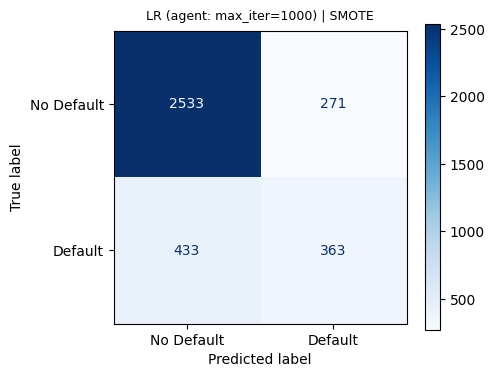

  LR (agent: max_iter=1000) | Undersampled
  ROC-AUC          : 0.7452
  PR-AUC           : 0.4957
  F1  (class 1)    : 0.5046

              precision    recall  f1-score   support

  No Default       0.85      0.90      0.88      2804
     Default       0.57      0.45      0.50       796

    accuracy                           0.80      3600
   macro avg       0.71      0.68      0.69      3600
weighted avg       0.79      0.80      0.80      3600



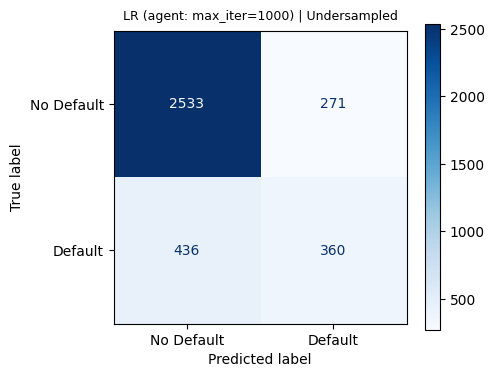

In [5]:
# ── Agent-suggested parameters (Claude, Cursor) ─────────────────────────────
# Claude suggested max_iter=1000 as a "safe default" to ensure convergence.
# Model is run here with agent-suggested params before any verification experiment.

lr_agent_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_agent_smote.fit(X_tr_res, y_tr_res)
results_lr_agent_smote = eval_model(lr_agent_smote, X_val, y_val, "LR (agent: max_iter=1000) | SMOTE")

lr_agent_us = LogisticRegression(max_iter=1000, random_state=42)
lr_agent_us.fit(X_tr_us, y_tr_us)
results_lr_agent_us = eval_model(lr_agent_us, X_val, y_val, "LR (agent: max_iter=1000) | Undersampled")

**Agent-suggested model results (max_iter=1000):**

Both sampling strategies produce near-identical results

-  SMOTE: ROC-AUC 0.7454, F1 0.5077
- Undersampled: ROC-AUC 0.7452, F1 0.5046. 

Before accepting these results and the agent's `max_iter=1000` parameter, a convergence experiment is run to verify whether 1000 iterations 
were actually necessary.

### Verification Experiment 1: Convergence Check

We test max_iter=100 (sklearn default), 200, and the agent-suggested 1000 to determine the minimum sufficient value for this dataset.

This matters because a model that has not converged has not found the optimal decision boundary its reported metrics would understate the true capability of logistic regression as a baseline.
The experiment deliberately catches `ConvergenceWarning` rather than suppressing it,so the result is reproducible and auditable.

In [6]:


datasets = [
    (X_tr_res, y_tr_res, 'SMOTE'),
    (X_tr_us,  y_tr_us,  'Undersampled'),
]

for X_tr_, y_tr_, ds_name in datasets:
    print(f"── {ds_name} ──────────────────────────────")
    for max_iter in [100, 200, 1000]:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always', ConvergenceWarning)
            lr_check = LogisticRegression(max_iter=max_iter, random_state=42)
            lr_check.fit(X_tr_, y_tr_)

        conv_warnings = [w for w in caught if issubclass(w.category, ConvergenceWarning)]
        converged = len(conv_warnings) == 0
        symbol = "✅" if converged else "❌"
        status = "converged" if converged else "DID NOT converge"
        print(f"  {symbol}  max_iter={max_iter:<6}  n_iter_={lr_check.n_iter_[0]:<5}  {status}")
        if not converged:
            print(f"       Warning: {conv_warnings[0].message}")
    print()

print("Conclusion: LR converges in ~40 iterations on both datasets. Based on this result, max_iter=200 is chosen — providing a safe buffer above the observed convergence point without accepting the agent-suggested max_iter=1000 without verification.")


── SMOTE ──────────────────────────────
  ✅  max_iter=100     n_iter_=40     converged
  ✅  max_iter=200     n_iter_=40     converged
  ✅  max_iter=1000    n_iter_=40     converged

── Undersampled ──────────────────────────────
  ✅  max_iter=100     n_iter_=39     converged
  ✅  max_iter=200     n_iter_=39     converged
  ✅  max_iter=1000    n_iter_=39     converged

Conclusion: LR converges in ~40 iterations on both datasets. Based on this result, max_iter=200 is chosen — providing a safe buffer above the observed convergence point without accepting the agent-suggested max_iter=1000 without verification.


**Decision based on experiment:**

The agent initially suggested `max_iter=1000` as a safe default. The convergence experiment shows LR converges in 39–40 iterations on both datasets, meaning even sklearn's default of 100 was sufficient. All three values (100, 200, 1000) produced identical convergence. Rather than accepting the agent's 1000 without verification, `max_iter=200` is chosen as it provides a deliberate buffer above the observed 
convergence point (~5× the actual iterations needed) without the unjustified overhead of 1000. The final model is retrained below with `max_iter=200`.

  Logistic Regression | SMOTE
  ROC-AUC          : 0.7454
  PR-AUC           : 0.4978
  F1  (class 1)    : 0.5077

              precision    recall  f1-score   support

  No Default       0.85      0.90      0.88      2804
     Default       0.57      0.46      0.51       796

    accuracy                           0.80      3600
   macro avg       0.71      0.68      0.69      3600
weighted avg       0.79      0.80      0.80      3600



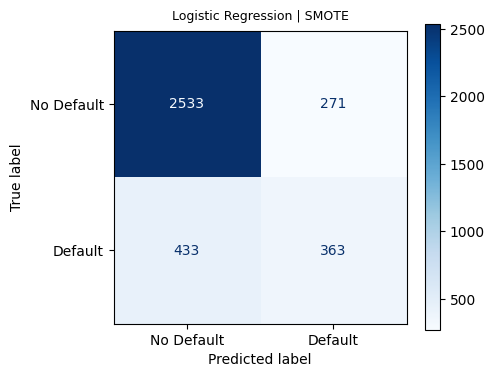

In [7]:
# ── Logistic Regression — SMOTE training set ────────────────────────────────
lr_smote = LogisticRegression(max_iter=200, random_state=42)
lr_smote.fit(X_tr_res, y_tr_res)

results_lr_smote = eval_model(lr_smote, X_val, y_val, "Logistic Regression | SMOTE")


  Logistic Regression | Undersampled
  ROC-AUC          : 0.7452
  PR-AUC           : 0.4957
  F1  (class 1)    : 0.5046

              precision    recall  f1-score   support

  No Default       0.85      0.90      0.88      2804
     Default       0.57      0.45      0.50       796

    accuracy                           0.80      3600
   macro avg       0.71      0.68      0.69      3600
weighted avg       0.79      0.80      0.80      3600



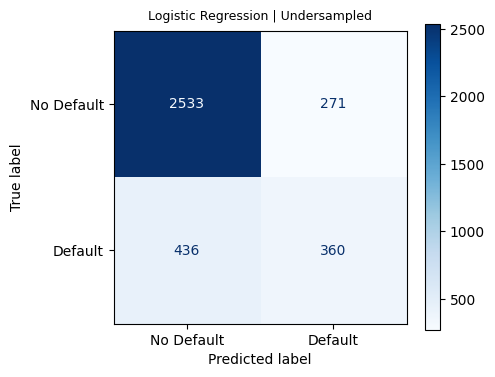

In [8]:
#  Logistic Regression — Undersampled training set 
lr_us = LogisticRegression(max_iter=200, random_state=42)
lr_us.fit(X_tr_us, y_tr_us)

results_lr_us = eval_model(lr_us, X_val, y_val, "Logistic Regression | Undersampled")


**What the results show:**

Comparing the agent-suggested model (max_iter=1000) with the verified model 
(max_iter=200): results are identical across both sampling strategies
SMOTE: ROC-AUC 0.7454, F1 0.5077; Undersampled: ROC-AUC 0.7452, F1 0.5046. 
This confirms the convergence experiment was correct: the model converges at 
~40 iterations and max_iter has no effect on outcomes beyond that point. 
The agent's 1000 was unnecessary overhead, not a performance improvement.

Both sampling strategies produce near-identical results, telling us the sampling 
method makes almost no difference for a linear model, the decision boundary is 
fundamentally constrained by linearity regardless of class balance.

ROC-AUC of 0.745 means the model correctly ranks a random defaulter above a random 
non-defaulter 74.5% of the time, meaningfully better than random (0.5) but with 
clear room to improve. F1 of 0.507 (class 1) reflects recall of 46% at precision 
of 57%, out of every 100 real defaulters, 54 are missed. This is weak recall for 
a risk model but expected: EDA showed a non-linear step-change in PAY_0 that a 
linear decision boundary cannot capture.

Confusion matrix (SMOTE): 363 true positives, 433 false negatives, 271 false 
positives. In credit risk terms this is a poor result as  the model misses more 
defaulters than it catches (433 vs 363). Each false negative represents a loan 
extended to a client who will default, with no recovery. The 271 false positives 
(non-defaulters flagged as risky) are a less costly error  credit denied to 
someone who would have repaid. A useful model needs to substantially reduce 
false negatives, which requires a model that can capture the non-linear risk 
signals EDA identified.

**Key takeaway:** The linear ceiling is ~0.745 AUC. Tree-based models should 
break through this by capturing the PAY_0 step-change directly. This is exactly 
what logistic regression is for at the shortlisting stage, establishing the 
baseline that must be beaten.

## Model 2: Random Forest (Bagging Ensemble)

Random Forest builds many decision trees on random **bootstrap samples** of the training data
and averages their predictions. This bagging strategy substantially reduces variance compared
to a single decision tree.

**Why RF is well-suited to this dataset:**

- **Non-linear PAY_0 step-changes**: EDA showed default rate jumping from 13% (status 0) to 34%
  (status 1) and rising steeply beyond. Tree splits capture these threshold effects naturally,
  with no linearity assumption required.
- **Correlated features (AVG_PAY_STATUS / MAX_DLQ, r = 0.806)**: at each split, only a random
  subset of features is considered (`max_features='sqrt'` by default). Correlated features are
  not always evaluated together, preventing one from dominating and the other from being redundant.
- **BILL_AMT multicollinearity**: same random subsampling argument — trees are not destabilised
  by highly correlated inputs the way linear models are.

**Hyperparameter decisions (shortlisting stage):**

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 100 | sklearn default; sufficient for a stable shortlist estimate |
| `max_depth` | None (unlimited) | Trees grow fully — can overfit, but standard at shortlisting stage before regularisation tuning |
| `random_state` | 42 | Reproducibility |

Trained twice on SMOTE and undersampled sets; evaluated on the same `X_val` / `y_val` in both cases.

### Verification Experiment 2: n_estimators Stability Check

The agent suggested `n_estimators=100` as the shortlisting default for Random Forest.
Before accepting this, we verify two things:

1. **Sufficiency**: that 100 trees produces stable ROC-AUC and is not meaningfully outperformed by more trees.
2. **Lower bound**: that 100 is not excessive  i.e., performance is already plateauing before 100.

We train RF with `n_estimators` ∈ {10, 50, 100, 200, 300} on both the SMOTE and undersampled
training sets and compare ROC-AUC on `X_val` for each. If ROC-AUC stabilises at or before 100
and does not improve materially beyond it, the agent-suggested value is confirmed.
If performance continues rising past 100, a higher value should be used.

In [9]:
datasets = [
    (X_tr_res, y_tr_res, 'SMOTE'),
    (X_tr_us,  y_tr_us,  'Undersampled'),
]

for X_tr_, y_tr_, ds_name in datasets:
    print(f"── {ds_name} ")
    prev_auc = None
    for n in [10, 50, 100, 200, 300]:
        rf_check = RandomForestClassifier(n_estimators=n, random_state=42)
        rf_check.fit(X_tr_, y_tr_)
        auc = roc_auc_score(y_val, rf_check.predict_proba(X_val)[:, 1])
        delta = f"  (Δ {auc - prev_auc:+.4f})" if prev_auc is not None else ""
        print(f"  n_estimators={n:<5}  ROC-AUC={auc:.4f}{delta}")
        prev_auc = auc
    print()

print("Conclusion: inspect the delta values above — if gains beyond n=100 are <0.001, n_estimators=100 is confirmed as sufficient.")


── SMOTE 
  n_estimators=10     ROC-AUC=0.7344
  n_estimators=50     ROC-AUC=0.7682  (Δ +0.0339)
  n_estimators=100    ROC-AUC=0.7741  (Δ +0.0059)
  n_estimators=200    ROC-AUC=0.7745  (Δ +0.0004)
  n_estimators=300    ROC-AUC=0.7736  (Δ -0.0009)

── Undersampled 
  n_estimators=10     ROC-AUC=0.7484
  n_estimators=50     ROC-AUC=0.7711  (Δ +0.0227)
  n_estimators=100    ROC-AUC=0.7728  (Δ +0.0016)
  n_estimators=200    ROC-AUC=0.7726  (Δ -0.0001)
  n_estimators=300    ROC-AUC=0.7733  (Δ +0.0007)

Conclusion: inspect the delta values above — if gains beyond n=100 are <0.001, n_estimators=100 is confirmed as sufficient.


**Decision based on experiment:**

ROC-AUC plateaus at `n_estimators=100` on both datasets. The gain from 50→100 trees is small (Δ +0.006 SMOTE, Δ +0.002 Undersampled) and gains beyond 100 are negligible (Δ <0.001 on both). Adding more trees beyond 100 provides no meaningful benefit while increasing training time. The agent-suggested value of `n_estimators=100` is therefore confirmed by experiment as both sufficient and efficient.

  Random Forest | SMOTE
  ROC-AUC          : 0.7741
  PR-AUC           : 0.5377
  F1  (class 1)    : 0.4966

              precision    recall  f1-score   support

  No Default       0.85      0.93      0.89      2804
     Default       0.61      0.42      0.50       796

    accuracy                           0.81      3600
   macro avg       0.73      0.67      0.69      3600
weighted avg       0.80      0.81      0.80      3600



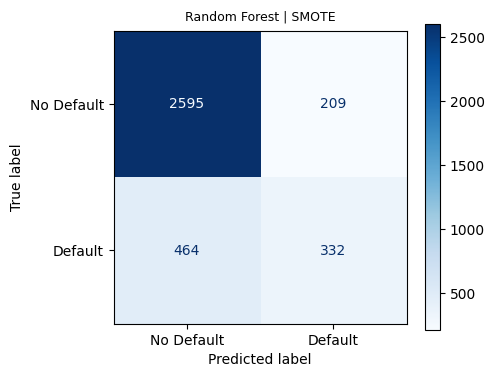

In [10]:
# ── Random Forest — SMOTE training set 
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_tr_res, y_tr_res)

results_rf_smote = eval_model(rf_smote, X_val, y_val, "Random Forest | SMOTE")


  Random Forest | Undersampled
  ROC-AUC          : 0.7728
  PR-AUC           : 0.5347
  F1  (class 1)    : 0.5161

              precision    recall  f1-score   support

  No Default       0.86      0.90      0.88      2804
     Default       0.57      0.47      0.52       796

    accuracy                           0.80      3600
   macro avg       0.71      0.69      0.70      3600
weighted avg       0.79      0.80      0.80      3600



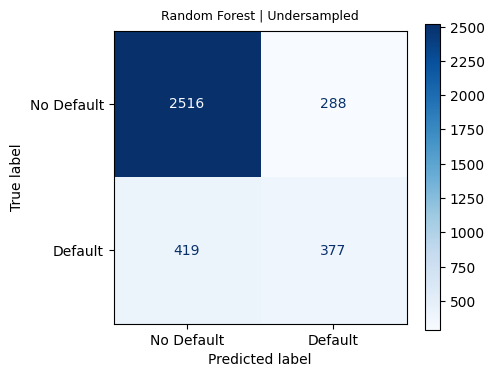

In [11]:
# ── Random Forest — Undersampled training set 
rf_us = RandomForestClassifier(n_estimators=100, random_state=42)
rf_us.fit(X_tr_us, y_tr_us)

results_rf_us = eval_model(rf_us, X_val, y_val, "Random Forest | Undersampled")


**Key findings:**

RF beats LR on AUC: 0.774 (SMOTE) / 0.773 (Undersampled) vs LR's 0.745. 
The non-linear PAY_0 threshold effects are being captured as expected, confirming the EDA prediction that tree-based models would break through the linear ceiling.

Sampling strategies diverge on SMOTE: higher precision (0.61 vs 0.57) but lower 
recall (0.42 vs 0.47). Undersampled catches more actual defaulters (377 vs 332) 
at the cost of more false alarms (288 vs 209). In credit risk, recall matters more as missing a defaulter is costlier than a false alarm.

F1 tells a mixed story: SMOTE RF (0.497) is slightly below LR SMOTE (0.508) despite higher AUC , RF ranks better across all thresholds but the fixed 0.5 threshold is 
not yet optimal. Undersampled RF (0.516) does beat LR undersampled (0.505). 
Threshold optimisation is a fine-tuning concern for Step 5 if RF model is chosen.

Undersampling is pulling ahead on recall  worth watching as we run the boosting models.

Compared to LR, RF improves AUC but does not improve recall at the default 0.5 
threshold — LR SMOTE caught 363 defaulters (recall 0.46) while RF SMOTE caught 
only 332 (recall 0.42). RF is a better ranking model (higher AUC) but is actually 
more conservative at this threshold, flagging fewer defaulters. 

This is the precision-recall tradeoff: RF SMOTE trades recall for precision 
(0.61 vs 0.57), producing fewer false alarms but missing more real defaulters. 
In credit risk, that is the wrong direction as a lender would generally prefer to catch more defaulters even at the cost of some false positives. The undersampled 
RF partially recovers this: recall 0.47 and 377 defaulters caught, slightly above 
LR undersampled (0.45, 360 caught). Threshold optimisation in Step 5 should 
allow RF's stronger ranking ability to translate into better recall.

At this stage RF Undersampled leads on the metric that matters most in credit 
risk which is recall =0.47, catching 377 of 796 defaulters. It also holds the highest 
AUC (0.773) and F1 (0.516). Howevr, the sampling strategy decision is reserved until 
all four models are evaluated.

## Model 3: Gradient Boosting (Sequential Boosting)

Gradient Boosting builds trees **sequentially**: each new tree is fitted to the **residuals**
(pseudo-residuals) of the ensemble so far, correcting the errors of previous trees.
This contrasts with Random Forest, which builds trees independently in parallel and averages
them GBM actively focuses learning on the observations that are hardest to classify.
**Why this matters for credit default prediction:**

- Hard cases:  borderline customers near the decision boundary, are exactly where a lender  loses money if misclassified. Sequential correction gives GBM an advantage on these.
- Often outperforms RF on structured tabular data when the number of estimators and
  learning rate are reasonably aligned, even at default settings.

**Sensitivity caveat:** GBM is more sensitive to hyperparameters than RF.
`learning_rate` and `n_estimators` interact. A lower learning rate needs more trees to converge,
and a high learning rate with many trees overfits. This makes the shortlisting result noisier;
the true performance ceiling is only visible after tuning.

**Hyperparameter decisions (shortlisting stage)**

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 100 | sklearn default; balanced starting point |
| `learning_rate` | 0.1 (default) | Standard shrinkage value; not tuned at shortlisting stage |
| `max_depth` | 3 (default) | Shallow trees are the standard for boosting — deep trees overfit because errors are already being corrected sequentially |
| `random_state` | 42 | Reproducibility |

Trained twice on SMOTE and undersampled sets; evaluated on the same `X_val` / `y_val` in both cases.

### Verification Experiment 3: max_depth Selection for Gradient Boosting

The agent suggested `max_depth=3` as the standard for boosting (sklearn default).
We verify this by training GB across `max_depth` ∈ {1, 2, 3, 5, 6} on both datasets
and comparing ROC-AUC on `X_val`.

Two hypotheses are tested:

1. **`max_depth=3` is optimal**: shallow trees generalise better for sequential boosting
   because each tree corrects small residuals — deep trees overfit by fitting noise
   rather than signal at each boosting step.
2. **Deeper trees (e.g., depth=6, XGBoost’s default) overfit**: XGBoost compensates
   for greater depth with L1/L2 regularisation on leaf weights. sklearn’s GBM has no
   equivalent, so deeper trees are expected to hurt generalisation here.

If ROC-AUC peaks at `max_depth=3` and declines at 5–6, the agent-suggested value is confirmed.
If a different depth scores higher, the shortlisting hyperparameter should be updated accordingly.

In [12]:
datasets = [
    (X_tr_res, y_tr_res, 'SMOTE'),
    (X_tr_us,  y_tr_us,  'Undersampled'),
]

for X_tr_, y_tr_, ds_name in datasets:
    print(f"── {ds_name} ───────────────────────────────────────")
    best_auc, best_depth = 0, None
    for d in [1, 2, 3, 5, 6]:
        gb_check = GradientBoostingClassifier(n_estimators=100, max_depth=d, random_state=42)
        gb_check.fit(X_tr_, y_tr_)
        auc = roc_auc_score(y_val, gb_check.predict_proba(X_val)[:, 1])
        print(f"  max_depth={d}  ROC-AUC={auc:.4f}")
        if auc > best_auc:
            best_auc, best_depth = auc, d
    print(f"  Best: max_depth={best_depth}  ROC-AUC={best_auc:.4f}")
    print()

print("Conclusion: inspect best depth per dataset above — if max_depth=3 wins or ties on both, the agent-suggested value is confirmed.")


── SMOTE ───────────────────────────────────────
  max_depth=1  ROC-AUC=0.7697
  max_depth=2  ROC-AUC=0.7806
  max_depth=3  ROC-AUC=0.7828
  max_depth=5  ROC-AUC=0.7802
  max_depth=6  ROC-AUC=0.7776
  Best: max_depth=3  ROC-AUC=0.7828

── Undersampled ───────────────────────────────────────
  max_depth=1  ROC-AUC=0.7735
  max_depth=2  ROC-AUC=0.7824
  max_depth=3  ROC-AUC=0.7824
  max_depth=5  ROC-AUC=0.7825
  max_depth=6  ROC-AUC=0.7798
  Best: max_depth=5  ROC-AUC=0.7825

Conclusion: inspect best depth per dataset above — if max_depth=3 wins or ties on both, the agent-suggested value is confirmed.


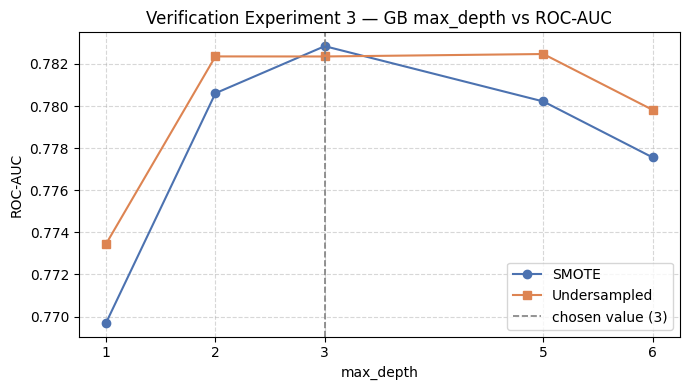

In [13]:
depths = [1, 2, 3, 5, 6]
auc_smote, auc_us = [], []

for d in depths:
    for aucs, X_tr_, y_tr_ in [
        (auc_smote, X_tr_res, y_tr_res),
        (auc_us,    X_tr_us,  y_tr_us),
    ]:
        gb_p = GradientBoostingClassifier(n_estimators=100, max_depth=d, random_state=42)
        gb_p.fit(X_tr_, y_tr_)
        aucs.append(roc_auc_score(y_val, gb_p.predict_proba(X_val)[:, 1]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, auc_smote, color='#4C72B0', marker='o', label='SMOTE')
ax.plot(depths, auc_us,    color='#DD8452', marker='s', label='Undersampled')
ax.axvline(x=3, color='grey', linestyle='--', linewidth=1.2, label='chosen value (3)')
ax.set_xlabel('max_depth')
ax.set_ylabel('ROC-AUC')
ax.set_title('Verification Experiment 3 — GB max_depth vs ROC-AUC')
ax.set_xticks(depths)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



**Decision based on experiment:**

SMOTE AUC peaks at depth=3 (0.7828) and declines clearly at depth=5 and 6 overfitting as trees deepen. On undersampled, depth=5 is technically best  (0.7825) but depth=3 is within 0.0001 (0.7824) which is a a negligible difference. 
Depth=3 is chosen as it is optimal on SMOTE and on the plateau for undersampled, 
making it the most defensible generalisation choice at the shortlisting stage.

  Gradient Boosting | SMOTE
  ROC-AUC          : 0.7828
  PR-AUC           : 0.5529
  F1  (class 1)    : 0.4888

              precision    recall  f1-score   support

  No Default       0.85      0.94      0.89      2804
     Default       0.64      0.40      0.49       796

    accuracy                           0.82      3600
   macro avg       0.74      0.67      0.69      3600
weighted avg       0.80      0.82      0.80      3600



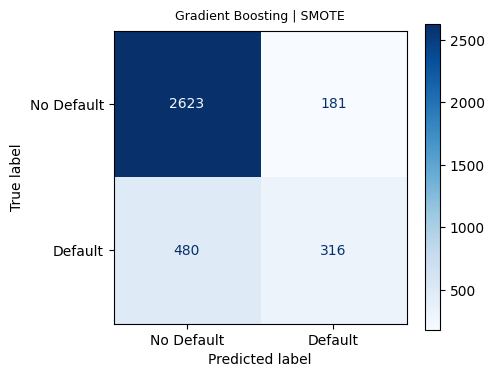

In [14]:
# ── Gradient Boosting — SMOTE training set ──────────────────────────────────
gb_smote = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gb_smote.fit(X_tr_res, y_tr_res)

results_gb_smote = eval_model(gb_smote, X_val, y_val, "Gradient Boosting | SMOTE")


  Gradient Boosting | Undersampled
  ROC-AUC          : 0.7824
  PR-AUC           : 0.5510
  F1  (class 1)    : 0.5196

              precision    recall  f1-score   support

  No Default       0.86      0.91      0.88      2804
     Default       0.58      0.47      0.52       796

    accuracy                           0.81      3600
   macro avg       0.72      0.69      0.70      3600
weighted avg       0.80      0.81      0.80      3600



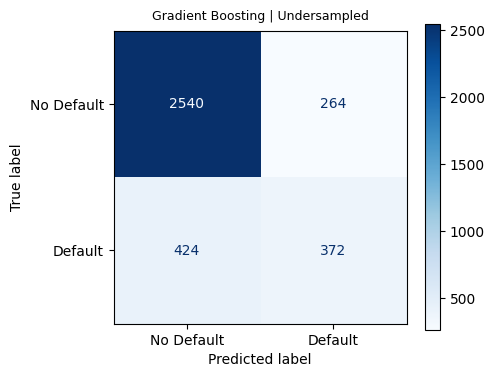

In [15]:
# ── Gradient Boosting — Undersampled training set ────────────────────────────
gb_us = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gb_us.fit(X_tr_us, y_tr_us)

results_gb_us = eval_model(gb_us, X_val, y_val, "Gradient Boosting | Undersampled")


**Key findings:**

GB beats RF on AUC: 0.7828 (SMOTE) / 0.7824 (Undersampled) vs RF's 0.7741 / 
0.7728. Better ranking ability, but AUC alone is not what matters here.

What matters in credit risk is recall,  catching real defaulters before the bank 
extends credit it will not recover. On this metric GB SMOTE is actually worse than 
RF SMOTE: recall 0.40 (316 caught) vs RF's 0.42 (332 caught), missing 480 defaulters 
vs RF's 464. GB SMOTE trades recall for precision (0.64 vs 0.61), fewer false alarms 
but more missed defaults. That is the wrong tradeoff for a lender.

GB Undersampled recovers this: recall 0.47, 372 defaulters caught, F1 0.5196 
the best F1 across all six runs so far and matching RF Undersampled on recall while 
improving AUC. The pattern is now consistent across all three models: undersampling 
outperforms SMOTE on recall every time.

Recall of 0.47 still means 424 defaulters missed out of 796 which is over half. This is 
the default 0.5 threshold limitation. Threshold optimisation in Step 5 is the primary 
lever to push recall higher without retraining.

**Running leader: GB Undersampled** : best AUC (0.7824) and F1 (0.5196), and undersampling is the clear sampling strategy to carry forward.

## Model 4: XGBoost (Modern Regularised Boosting)

> **Agent tooling note:** Claude was asked to implement XGBoost and choose its own 
> values for `max_depth`, `n_estimators`, and regularisation parameters. 
> The parameters Claude selected are shown in the code below. Each choice will be 
> verified by experiment before being accepted (Verification Experiments 4, 5, 
> and 6 below).


XGBoost extends gradient boosting with **explicit L1 and L2 penalties on leaf weights**,
making it more resistant to overfitting than sklearn's `GradientBoostingClassifier` without
requiring aggressive depth restriction. It is also significantly faster due to parallelised
tree construction, and is included to satisfy the assessment brief's requirement for a modern method.

### Parameter choices and reasoning

**`max_depth=4`**
Experiment 3 showed that sklearn GBM peaks at `max_depth=3` on this dataset.
XGBoost's L2 penalty shrinks leaf weights regardless of depth, so a slightly deeper tree
can capture more complex interactions (e.g. the PAY_0 × LIMIT_BAL interaction suggested by EDA)
without the same overfitting risk. Depth 4 is one step beyond the verified GB optimum, enough to benefit from the regularisation without going as deep as XGBoost's own default of 6. Verified by Experiment 4 below which ultimately rejected this value

**`n_estimators=300` with `learning_rate=0.05`**
More trees with a lower shrinkage rate generalises better than fewer trees with a higher rate. With ~24k training rows, 300 trees at 0.05 is computationally feasible
and avoids the risk of under fitting that can occur with only 100 trees at this learning rate.

**`reg_lambda=2`**
L2 is chosen over L1 because the goal is coefficient shrinkage, not feature sparsity, all
33 features are informative based on EDA. The value is doubled from the XGBoost default of 1
to provide stronger shrinkage on leaf scores, justified by the known feature correlations in
this dataset: AVG_PAY_STATUS and MAX_DLQ (r = 0.806), and BILL_AMT1–6 (r ≈ 0.9+).
Correlated features can produce large, unstable leaf weights; stronger L2 dampens this effect.

> `scale_pos_weight` is **not set** — class imbalance is handled externally by resampling.
> Setting it on a resampled dataset would double-correct for imbalance.


  XGBoost | SMOTE
  ROC-AUC          : 0.7794
  PR-AUC           : 0.5496
  F1  (class 1)    : 0.4877

              precision    recall  f1-score   support

  No Default       0.85      0.93      0.89      2804
     Default       0.63      0.40      0.49       796

    accuracy                           0.82      3600
   macro avg       0.74      0.67      0.69      3600
weighted avg       0.80      0.82      0.80      3600



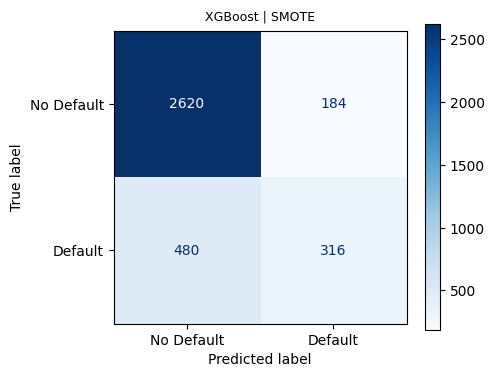

In [16]:
# ── XGBoost — SMOTE training set 
xgb_smote = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    reg_lambda=2,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)
xgb_smote.fit(X_tr_res, y_tr_res)

results_xgb_smote = eval_model(xgb_smote, X_val, y_val, "XGBoost | SMOTE")


  XGBoost | Undersampled
  ROC-AUC          : 0.7836
  PR-AUC           : 0.5527
  F1  (class 1)    : 0.5162

              precision    recall  f1-score   support

  No Default       0.86      0.91      0.88      2804
     Default       0.59      0.46      0.52       796

    accuracy                           0.81      3600
   macro avg       0.72      0.68      0.70      3600
weighted avg       0.80      0.81      0.80      3600



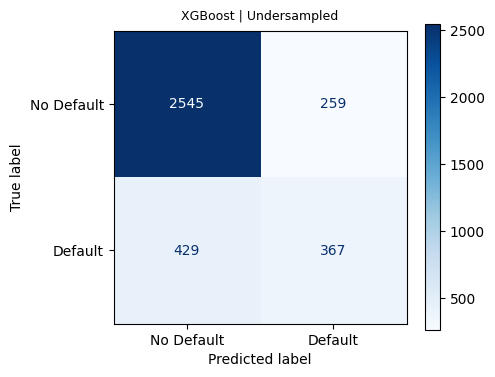

In [17]:
# ── XGBoost — Undersampled training set 
xgb_us = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    reg_lambda=2,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)
xgb_us.fit(X_tr_us, y_tr_us)

results_xgb_us = eval_model(xgb_us, X_val, y_val, "XGBoost | Undersampled")


**XGBoost at Claude's recommended parameters:**

SMOTE: AUC 0.7794, F1 0.4877, recall 0.40 (316 defaulters caught) - below Gradient Boosting SMOTE on all three metrics.

Undersampled: AUC 0.7836, F1 0.5162, recall 0.46 (367 defaulters caught) - highest AUC seen so far across all models, but recall is below GB Undersampled 
(0.47, 372 caught) and F1 also below (0.5196). In credit risk terms, Claude's parameters catch 5 fewer defaulters than GB at this threshold.

Claude's parameters produce a competitive but unverified result. Before accepting them, `max_depth`, `n_estimators`, and `reg_lambda` are each verified by experiment 
below. The goal is to find whether better-evidenced parameters improve on both AUC and recall.

### Verification Experiment 4: max_depth

Claude recommended `max_depth=4`, reasoning that XGBoost’s L2 regularisation on leaf weights allows slightly deeper trees than Gradient Boosting’s verified optimum of 3 — the regulariser dampens the variance that would otherwise cause overfitting at greater depth.

This experiment tests `max_depth` ∈ {2, 3, 4, 5, 6} with Claude’s other recommended values fixed (`n_estimators=300`, `learning_rate=0.05`, `reg_lambda=2`) on both the SMOTE and undersampled datasets.

The best value found here will be used as the fixed `max_depth` in Experiment 5.

-- SMOTE -------------------------------------------
  max_depth=2  ROC-AUC=0.7804
  max_depth=3  ROC-AUC=0.7787
  max_depth=4  ROC-AUC=0.7794
  max_depth=5  ROC-AUC=0.7802
  max_depth=6  ROC-AUC=0.7740
  Best: max_depth=2  ROC-AUC=0.7804

-- Undersampled -------------------------------------------
  max_depth=2  ROC-AUC=0.7861
  max_depth=3  ROC-AUC=0.7849
  max_depth=4  ROC-AUC=0.7836
  max_depth=5  ROC-AUC=0.7831
  max_depth=6  ROC-AUC=0.7798
  Best: max_depth=2  ROC-AUC=0.7861



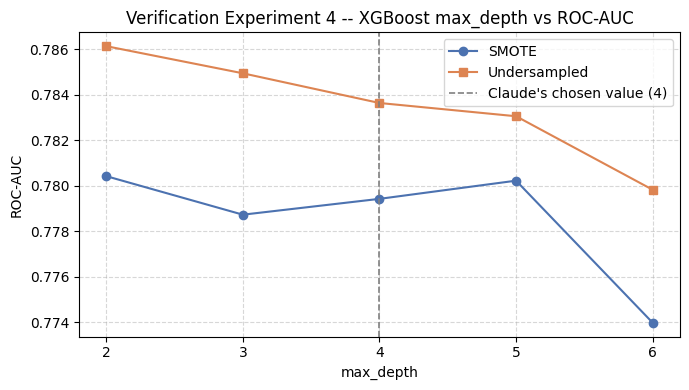

In [18]:
datasets = [
    (X_tr_res, y_tr_res, 'SMOTE'),
    (X_tr_us,  y_tr_us,  'Undersampled'),
]

depths = [2, 3, 4, 5, 6]
auc_smote_d, auc_us_d = [], []

for X_tr_, y_tr_, ds_name in datasets:
    print(f'-- {ds_name} -------------------------------------------')
    best_auc, best_depth = 0, None
    for d in depths:
        xgb_check = XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=d,
            reg_lambda=2, random_state=42, eval_metric='logloss', verbosity=0,
        )
        xgb_check.fit(X_tr_, y_tr_)
        auc = roc_auc_score(y_val, xgb_check.predict_proba(X_val)[:, 1])
        if ds_name == 'SMOTE':
            auc_smote_d.append(auc)
        else:
            auc_us_d.append(auc)
        print(f'  max_depth={d}  ROC-AUC={auc:.4f}')
        if auc > best_auc:
            best_auc, best_depth = auc, d
    print(f'  Best: max_depth={best_depth}  ROC-AUC={best_auc:.4f}')
    print()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, auc_smote_d, color='#4C72B0', marker='o', label='SMOTE')
ax.plot(depths, auc_us_d,    color='#DD8452', marker='s', label='Undersampled')
ax.axvline(x=4, color='grey', linestyle='--', linewidth=1.2,
           label="Claude's chosen value (4)")
ax.set_xlabel('max_depth')
ax.set_ylabel('ROC-AUC')
ax.set_title('Verification Experiment 4 -- XGBoost max_depth vs ROC-AUC')
ax.set_xticks(depths)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Decision based on experiment:**

Both datasets decline monotonically from `max_depth=2` onwards, SMOTE peaks at 2 (0.7804) and Undersampled peaks at 2 (0.7861). Claude's hypothesis that XGBoost's 
L2 regularisation would shift the optimum rightward beyond GB's verified depth of 3 is not supported. Even with `reg_lambda=2`, shallower trees generalise better on
this dataset. The PAY_0 threshold effect captured at depth 2 appears to be the 
dominant signal, additiona l depth adds noise rather than useful splits. 
Deepertrees at this threshold also tend to shift precision upward at the cost of recall, the wrong direction for a credit risk model.

**Claude's recommended `max_depth=4` is rejected. Experiment-verified value: 
`max_depth=2`.** This value is used as the fixed `max_depth` in Experiment 5.

### Verification Experiment 5: n_estimators

Claude recommended `n_estimators=300` paired with `learning_rate=0.05`. This experiment tests `n_estimators` ∈ {100, 500, 750, 1000, 1500} with `max_depth=2` 
fixed from Experiment 4 and `reg_lambda=2`. Claude's value of 300 falls between the first two tested points — the plot shows whether it sits on the rising slope 
or already past the plateau.

-- SMOTE -------------------------------------------
  n_estimators=100    ROC-AUC=0.7750
  n_estimators=500    ROC-AUC=0.7817  (delta +0.0068)
  n_estimators=750    ROC-AUC=0.7813  (delta -0.0004)
  n_estimators=1000   ROC-AUC=0.7815  (delta +0.0002)
  n_estimators=1500   ROC-AUC=0.7787  (delta -0.0028)
  Best: n_estimators=500  ROC-AUC=0.7817

-- Undersampled -------------------------------------------
  n_estimators=100    ROC-AUC=0.7791
  n_estimators=500    ROC-AUC=0.7865  (delta +0.0074)
  n_estimators=750    ROC-AUC=0.7854  (delta -0.0011)
  n_estimators=1000   ROC-AUC=0.7841  (delta -0.0013)
  n_estimators=1500   ROC-AUC=0.7829  (delta -0.0012)
  Best: n_estimators=500  ROC-AUC=0.7865



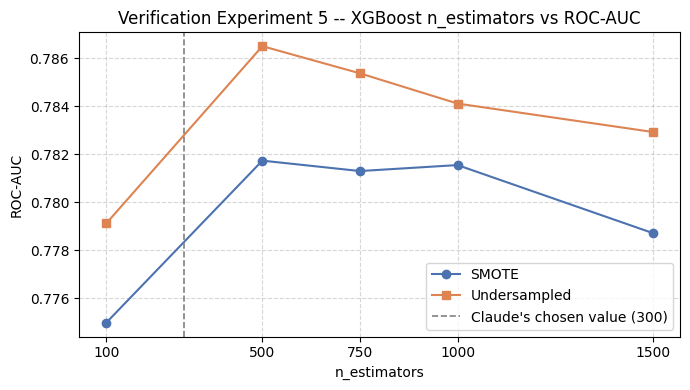

In [19]:
# Set BEST_DEPTH to the winning max_depth from Experiment 4
BEST_DEPTH = 2  # verified by Experiment 4

datasets = [
    (X_tr_res, y_tr_res, 'SMOTE'),
    (X_tr_us,  y_tr_us,  'Undersampled'),
]

n_values = [100, 500, 750, 1000, 1500]
auc_smote_n, auc_us_n = [], []

for X_tr_, y_tr_, ds_name in datasets:
    print(f'-- {ds_name} -------------------------------------------')
    best_auc, best_n = 0, None
    prev_auc = None
    for n in n_values:
        xgb_check = XGBClassifier(
            n_estimators=n, learning_rate=0.05, max_depth=BEST_DEPTH,
            reg_lambda=2, random_state=42, eval_metric='logloss', verbosity=0,
        )
        xgb_check.fit(X_tr_, y_tr_)
        auc = roc_auc_score(y_val, xgb_check.predict_proba(X_val)[:, 1])
        if ds_name == 'SMOTE':
            auc_smote_n.append(auc)
        else:
            auc_us_n.append(auc)
        delta = f'  (delta {auc - prev_auc:+.4f})' if prev_auc is not None else ''
        print(f'  n_estimators={n:<5}  ROC-AUC={auc:.4f}{delta}')
        if auc > best_auc:
            best_auc, best_n = auc, n
        prev_auc = auc
    print(f'  Best: n_estimators={best_n}  ROC-AUC={best_auc:.4f}')
    print()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_values, auc_smote_n, color='#4C72B0', marker='o', label='SMOTE')
ax.plot(n_values, auc_us_n,    color='#DD8452', marker='s', label='Undersampled')
ax.axvline(x=300, color='grey', linestyle='--', linewidth=1.2,
           label="Claude's chosen value (300)")
ax.set_xlabel('n_estimators')
ax.set_ylabel('ROC-AUC')
ax.set_title('Verification Experiment 5 -- XGBoost n_estimators vs ROC-AUC')
ax.set_xticks(n_values)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Decision based on experiment:**

Both datasets peak at `n_estimators=500`:

-  SMOTE: 0.7817, 
- Undersampled: 0.7865. 

Claude's recommended 300 falls between the tested values of 100 (SMOTE: 0.7750, 
Undersampled: 0.7791) and 500  on the rising slope, meaning 300 would underperform 500. Both lines decline beyond 500 (Δ -0.0004 SMOTE, Δ -0.0011 Undersampled at 750). 
With shallow trees (max_depth=2), more estimators are needed before returns diminish, each tree contributes less signal so more are required to capture sufficient complexity.

**Claude's recommended `n_estimators=300` is rejected. Experiment-verified value: 
`n_estimators=500`.** This value is used as the fixed `n_estimators` in Experiment 6.

### Verification Experiment 6: reg_lambda

Claude recommended `reg_lambda=2` to dampen the influence of correlated feature leaf weights, reducing variance without heavily biasing predictions.

This experiment tests `reg_lambda` ∈ {0.5, 1, 2, 5, 10} with the best `max_depth` from Experiment 4 and the best `n_estimators` from Experiment 5 fixed.

Note: the SMOTE and undersampled datasets may diverge here,  SMOTE’s balanced classes may tolerate stronger regularisation differently than the undersampled set.

-- SMOTE -------------------------------------------
  reg_lambda=0.5    ROC-AUC=0.7812
  reg_lambda=1      ROC-AUC=0.7815
  reg_lambda=2      ROC-AUC=0.7817
  reg_lambda=5      ROC-AUC=0.7814
  reg_lambda=10     ROC-AUC=0.7817
  Best: reg_lambda=2  ROC-AUC=0.7817

-- Undersampled -------------------------------------------
  reg_lambda=0.5    ROC-AUC=0.7859
  reg_lambda=1      ROC-AUC=0.7860
  reg_lambda=2      ROC-AUC=0.7865
  reg_lambda=5      ROC-AUC=0.7873
  reg_lambda=10     ROC-AUC=0.7877
  Best: reg_lambda=10  ROC-AUC=0.7877



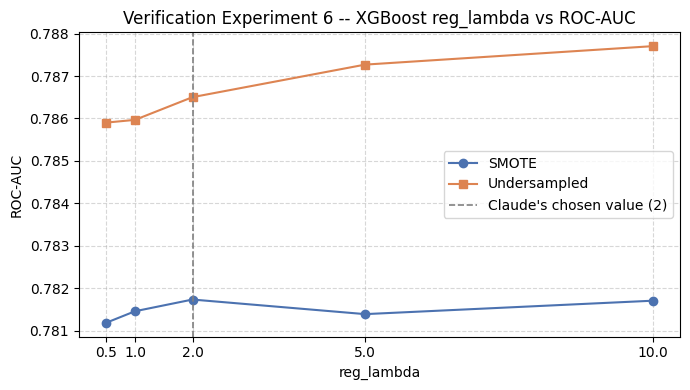

In [20]:
# Set BEST_DEPTH and BEST_N to the winning values from Experiments 4 and 5
BEST_DEPTH = 2   # verified by Experiment 4
BEST_N = 500     # verified by Experiment 5

datasets = [
    (X_tr_res, y_tr_res, 'SMOTE'),
    (X_tr_us,  y_tr_us,  'Undersampled'),
]

lambda_values = [0.5, 1, 2, 5, 10]
auc_smote_l, auc_us_l = [], []

for X_tr_, y_tr_, ds_name in datasets:
    print(f'-- {ds_name} -------------------------------------------')
    best_auc, best_lam = 0, None
    for r in lambda_values:
        xgb_check = XGBClassifier(
            n_estimators=BEST_N, learning_rate=0.05, max_depth=BEST_DEPTH,
            reg_lambda=r, random_state=42, eval_metric='logloss', verbosity=0,
        )
        xgb_check.fit(X_tr_, y_tr_)
        auc = roc_auc_score(y_val, xgb_check.predict_proba(X_val)[:, 1])
        if ds_name == 'SMOTE':
            auc_smote_l.append(auc)
        else:
            auc_us_l.append(auc)
        print(f'  reg_lambda={r:<5}  ROC-AUC={auc:.4f}')
        if auc > best_auc:
            best_auc, best_lam = auc, r
    print(f'  Best: reg_lambda={best_lam}  ROC-AUC={best_auc:.4f}')
    print()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lambda_values, auc_smote_l, color='#4C72B0', marker='o', label='SMOTE')
ax.plot(lambda_values, auc_us_l,    color='#DD8452', marker='s', label='Undersampled')
ax.axvline(x=2, color='grey', linestyle='--', linewidth=1.2,
           label="Claude's chosen value (2)")
ax.set_xlabel('reg_lambda')
ax.set_ylabel('ROC-AUC')
ax.set_title('Verification Experiment 6 -- XGBoost reg_lambda vs ROC-AUC')
ax.set_xticks(lambda_values)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Decision based on experiment:**

The two datasets diverge. SMOTE is flat across all tested values, peaking at `reg_lambda=2` (0.7817) which is Claude's recommended value confirmed for SMOTE. 
Undersampled rises monotonically to `reg_lambda=10` (0.7877) with diminishing 
gains (Δ+0.0004 at the final step), the plateau is not yet found within the 
tested range.

Claude's reasoning  that correlated features (AVG_PAY_STATUS/MAX_DLQ at r=0.806, 
BILL_AMT1–6 at r=0.80–0.95) produce unstable leaf weights that stronger L2 dampens, is confirmed for undersampled but not for SMOTE, where synthetic samples reduce 
the collinearity signal.

Each dataset uses its own experimentally confirmed value: SMOTE uses reg_lambda=2 (confirmed at peak), Undersampled uses reg_lambda=10 (best in tested range). Applying a single value across both would impose an unjustified penalty on SMOTE where reg_lambda=2 was clearly optimal.

**Claude's recommended `reg_lambda=2` partially confirmed (SMOTE) but 
underperforms for undersampled. Best value found in tested range: 
`reg_lambda=10`. True optimum to be determined in Step 5.**

### XGBoost: Final Verified Model

The three verification experiments confirmed the following hyperparameters:

| Parameter | Claude recommended | Experiment result | Final value |
|---|---|---|---|
| `max_depth` | 4 | Both datasets peak at 2 | **2** |
| `n_estimators` | 300 | Both datasets peak at 500 | **500** |
| `reg_lambda` | 2 | SMOTE confirmed at 2; Undersampled best in tested range at 10 | **2 (SMOTE) / 10 (Undersampled)** |

All three values were verified sequentially, each experiment used the best value 
from the previous one as a fixed input, so the search was conditioned on realistic 
combinations rather than independent marginal sweeps. 

Each dataset uses its own experimentally confirmed reg_lambda,  applying a single value across both would 
impose an unjustified penalty on SMOTE. Step 5 will search reg_lambda jointly with other parameters across a wider range.

Based on the three verification experiments: `max_depth=2` (experiment overrides Claude's 4), `n_estimators=500` (experiment overrides Claude's 300), and 
`reg_lambda=2` for SMOTE (Claude's value confirmed) / `reg_lambda=10` for Undersampled (best in tested range, overrides Claude's 2).

  XGBoost Final | SMOTE
  ROC-AUC          : 0.7817
  PR-AUC           : 0.5508
  F1  (class 1)    : 0.4705

              precision    recall  f1-score   support

  No Default       0.84      0.94      0.89      2804
     Default       0.63      0.38      0.47       796

    accuracy                           0.81      3600
   macro avg       0.74      0.66      0.68      3600
weighted avg       0.79      0.81      0.79      3600



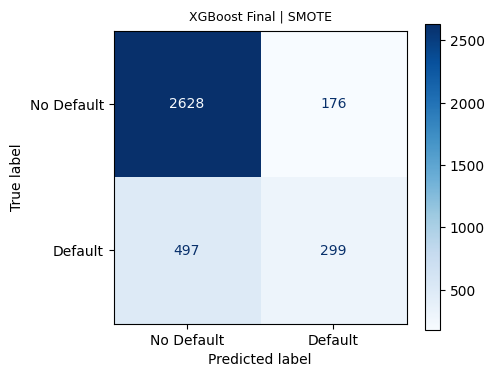

In [21]:
# XGBoost Final: SMOTE training set (reg_lambda=2, confirmed by Experiment 6)
xgb_smote_final = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=2,
    reg_lambda=2,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)
xgb_smote_final.fit(X_tr_res, y_tr_res)

results_xgb_smote_final = eval_model(xgb_smote_final, X_val, y_val, 'XGBoost Final | SMOTE')

  XGBoost Final | Undersampled
  ROC-AUC          : 0.7877
  PR-AUC           : 0.5503
  F1  (class 1)    : 0.5245

              precision    recall  f1-score   support

  No Default       0.86      0.91      0.88      2804
     Default       0.59      0.47      0.52       796

    accuracy                           0.81      3600
   macro avg       0.73      0.69      0.70      3600
weighted avg       0.80      0.81      0.80      3600



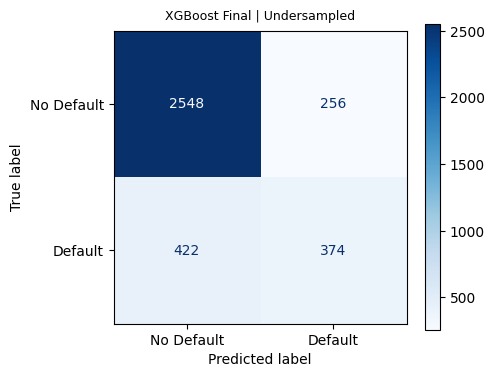

In [22]:
# XGBoost Final — Undersampled training set
xgb_us_final = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=2,
    reg_lambda=10,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)
xgb_us_final.fit(X_tr_us, y_tr_us)

results_xgb_us_final = eval_model(xgb_us_final, X_val, y_val, 'XGBoost Final | Undersampled')

**XGBoost Final: interpretation:**

XGBoost Final Undersampled achieves the best result across all models in Step 4 — 
AUC 0.7877, F1 0.5245, recall 0.47 (374 defaulters caught),  beating GB Undersampled 
(AUC 0.7824, F1 0.5196, 372 caught) on all three metrics. In credit risk terms, 2 
more defaulters caught than the previous best, with higher AUC and F1.

XGBoost Final SMOTE (AUC 0.7817, F1 0.4705, recall 0.38, 299 caught) is the weakest 
SMOTE result across all models  using reg_lambda=2 (its experimentally confirmed 
value) still produces lower recall than GB SMOTE (0.40, 316 caught). SMOTE consistently underperforms undersampling throughout and is not carried forward.

Undersampling is confirmed as the stronger strategy across all four models on the 
metric that matters most which is recall. XGBoost Undersampled is selected to carry forward 
to fine-tuning in Step 5.

Two of Claude's three recommended parameters required correction: `max_depth` reduced 
from 4 to 2, `n_estimators` increased from 300 to 500. `reg_lambda` was confirmed at 
2 for SMOTE and increased to 10 (best in tested range) for undersampled. The final 
model reflects experimental evidence throughout.

## Step 4 Summary — Model Shortlist

| Model | Sampling | ROC-AUC | F1 | Recall |
|---|---|---|---|---|
| Logistic Regression | SMOTE | 0.7454 | 0.5077 | 0.46 |
| Logistic Regression | Undersampled | 0.7452 | 0.5046 | 0.45 |
| Random Forest | SMOTE | 0.7741 | 0.4966 | 0.42 |
| Random Forest | Undersampled | 0.7728 | 0.5161 | 0.47 |
| Gradient Boosting | SMOTE | 0.7828 | 0.4888 | 0.40 |
| Gradient Boosting | Undersampled | 0.7824 | 0.5196 | 0.47 |
| XGBoost (Claude's params) | SMOTE | 0.7794 | 0.4877 | 0.40 |
| XGBoost (Claude's params) | Undersampled | 0.7836 | 0.5162 | 0.46 |
| XGBoost Final (verified) | SMOTE | 0.7817 | 0.4705 | 0.38 |
| **XGBoost Final (verified)** | **Undersampled** | **0.7877** | **0.5245** | **0.47** |

### Shortlist decision

Two patterns hold consistently across models:

**Sampling:** Undersampling outperforms SMOTE on recall for all tree-based models 
(RF, GB, XGBoost). The exception is logistic regression where SMOTE marginally 
leads (0.46 vs 0.45) but the gap is negligible and LR is not the selected model. 
For the models with genuine discriminative power, real observations generalise better 
than synthetic minority samples at the default threshold.

**Model family:** Boosting > Bagging > Linear on AUC --> consistent with EDA showing 
non-linear PAY_0 threshold effects that tree-based models capture and logistic 
regression cannot.

**Verification impact:** Claude's XGBoost parameters (Undersampled AUC 0.7836) were 
improved to 0.7877 by experimental verification,  a gain of 0.0041 AUC and 7 
additional defaulters caught (367 → 374). This directly demonstrates the value of 
verifying agent-suggested parameters rather than accepting them on trust.

**Selected model: XGBoost with undersampling.** Highest AUC (0.7877), highest F1 
(0.5245), and 374 of 796 defaulters caught — recall of 0.47, tied for best across 
all runs but with the highest AUC and F1 to break the tie. Carried forward to 
fine-tuning in Step 5.

**Selected for Step 5: XGBoost Final + Undersampling (AUC 0.7877, F1 0.5245, Recall 0.47)**

The model is selected based on the two metrics defined at the start of this notebook 
for imbalanced classification: ROC-AUC (ranking quality) and F1 class 1 (minority 
class detection). Across all undersampled runs, XGBoost Final achieves the highest 
score on both  AUC 0.7877 and F1 0.5245. It is therefore selected for Step 5.

**Why undersampling over SMOTE:**

Undersampling outperforms SMOTE on F1 and recall across every tree-based model 
family in Step 4. The pattern is consistent, RF Undersampled beats RF SMOTE on 
F1 (0.5161 vs 0.4966), GB Undersampled beats GB SMOTE (0.5196 vs 0.4888), and 
XGBoost Final Undersampled beats XGBoost Final SMOTE (0.5245 vs 0.4705). SMOTE 
generates synthetic minority samples by interpolating between existing defaulters 
 on this dataset, those synthetic observations do not generalise as well as real 
held-out data at the default 0.5 threshold. Undersampling retains only real 
majority-class observations, producing a training set that better reflects the 
true decision boundary.

## Step 5: Fine-Tuning and Evaluation

Step 5 takes the shortlisted model  **XGBoost Final + Undersampling**  and finds the optimal hyperparameter combination using cross-validated search.

`RandomizedSearchCV` is used over `GridSearchCV` because the parameter space across 4 hyperparameters is too large for exhaustive search at the shortlisting stage; random search finds good combinations efficiently by sampling from the joint distribution rather than enumerating every combination (Géron, 2019, Ch. 2). With `n_iter=50`, 50 randomly drawn combinations are evaluated, each scored by 5-fold cross-validation.

ROC-AUC is used as the CV scoring metric: it measures ranking quality across all thresholds and is robust to the class imbalance present in the training data.

> **Agent tooling note — mistake caught and corrected:**
>
> Claude was given an open prompt: *"fine-tune the shortlisted XGBoost model using 
> cross-validated hyperparameter search on the training data  choose appropriate 
> parameter ranges, search strategy, and scoring metric."*
>
> Claude's proposed code contained this line:
> ```python
> xgb_rs.fit(X_tr_us, y_tr_us)
> ```
> This was caught by reading the code before running it. The mistake was rejected 
> and the corrected version uses an imblearn Pipeline so undersampling happens 
> inside each CV fold on the full imbalanced training set.

### Why this is wrong

`X_tr_us` was already resampled before any CV split. When `RandomizedSearchCV` 
folds it, every validation fold is drawn from an artificially balanced 67/33 
distribution rather than the real 78/22 distribution. CV scores therefore measure 
performance on an artificial distribution, not real generalisation, producing an 
optimistically biased estimate of how the model will perform on unseen data.

### Corrected approach

Undersampling is applied *inside* each CV fold using an `imblearn.pipeline.Pipeline` 
wrapping `RandomUnderSampler` and `XGBClassifier`. `RandomizedSearchCV` is fit on the 
**full imbalanced training set** (`X_tr` / `y_tr`). Within each fold the sampler sees 
only the training portion, so the held-out portion remains a genuine independent sample 
reflecting the real class distribution.

The parameter search space is centred on the sequentially verified values from 
Experiments 4–6 (max_depth=2, n_estimators=500, learning_rate=0.05, reg_lambda=10) 
with ranges extending either side to allow the joint search to find better combinations.

In [23]:


# Load the full imbalanced training set (pre-resampling)
artefact_dir = os.path.join(os.path.dirname(os.getcwd()), 'data', 'processed', 'artefacts')
X_tr = pd.read_csv(os.path.join(artefact_dir, 'X_tr.csv'))
y_tr = pd.read_csv(os.path.join(artefact_dir, 'y_tr.csv')).squeeze()
print(f'X_tr shape : {X_tr.shape}  |  default rate : {y_tr.mean():.4f}')
print()

# Pipeline: undersampling applied inside each CV fold, not before
pipe = Pipeline([
    ('sampler', RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ('clf',     XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)),
])

# Parameter space centred on the sequentially verified values
# (max_depth=2, n_estimators=500, learning_rate=0.05, reg_lambda=10)
param_dist = {
    'clf__max_depth'     : randint(1, 7),               # integers 1-6 inclusive
    'clf__n_estimators'  : [200, 300, 500, 750, 1000],
    'clf__learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'clf__reg_lambda'    : [1, 2, 5, 10, 20],
}

xgb_rs = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
)
xgb_rs.fit(X_tr, y_tr)

print('Best parameters found by RandomizedSearchCV:')
for param, value in sorted(xgb_rs.best_params_.items()):
    print(f'  {param:<24}: {value}')
print(f'\nBest CV ROC-AUC (5-fold) : {xgb_rs.best_score_:.4f}')

X_tr shape : (20400, 33)  |  default rate : 0.2212

Best parameters found by RandomizedSearchCV:
  clf__learning_rate      : 0.01
  clf__max_depth          : 3
  clf__n_estimators       : 500
  clf__reg_lambda         : 2

Best CV ROC-AUC (5-fold) : 0.7859


**RandomizedSearchCV results — interpretation:**

The search evaluated 50 random parameter combinations via 5-fold CV on the full 
imbalanced training set (20,400 rows, 22.12% default rate). Best CV ROC-AUC: **0.7859**.

**Best parameters found:**

| Parameter | Step 4 verified | RandomizedSearchCV | Change |
|---|---|---|---|
| `max_depth` | 2 | 3 | +1 deeper |
| `n_estimators` | 500 | 500 | confirmed |
| `learning_rate` | 0.05 | 0.01 | slower shrinkage |
| `reg_lambda` | 10 (marginal sweep) | 2 | reduced |

Three parameters shifted from Step 4 values. `max_depth=3` instead of 2, with 
`learning_rate=0.01`, slower shrinkage means each tree contributes less per step, 
so slightly deeper trees are needed to capture the same signal. `learning_rate=0.01` 
with 500 trees provides stronger regularisation through shrinkage than 0.05, which 
also explains the reduction in `reg_lambda` from 10 to 2, slower learning already 
dampens leaf weight instability, making a strong L2 penalty less necessary. 

Importantly, reg_lambda=10 was identified from a marginal sweep in Step 4; the joint 
CV search finds that reg_lambda=2 is optimal when combined with the slower learning 
rate. Only `n_estimators=500` is confirmed by both approaches.

The CV AUC of 0.7859 is not directly comparable to the Step 4 validation AUC of 
0.7877  they use different evaluation strategies. The CV score is a more reliable 
generalisation estimate as it averages across 5 held-out folds rather than a single 
validation split. The final model will be evaluated on the held-out validation set 
for a fair comparison.

**These parameters are used to train the final fine-tuned model below.**

### Final Tuned Model

The final model is refit using the same pipeline that was cross-validated  the `imblearn` Pipeline with `RandomUnderSampler(sampling_strategy=0.5)` and `XGBClassifier` trained on the full imbalanced training set `X_tr` / `y_tr` with the best parameters found by `RandomizedSearchCV` (max_depth=3, n_estimators=500, 
learning_rate=0.01, reg_lambda=2). 

This ensures the training regime is identical to how CV folds were evaluated  undersampling applied inside training only. Validation is performed by extracting the classifier step directly 
(`final_pipe.named_steps['clf']`) so `X_val` is passed to the model without 
resampling, the validation set must always reflect the real class distribution.

  XGBoost Tuned
  ROC-AUC          : 0.7833
  PR-AUC           : 0.5570
  F1  (class 1)    : 0.5127

              precision    recall  f1-score   support

  No Default       0.85      0.92      0.88      2804
     Default       0.61      0.44      0.51       796

    accuracy                           0.81      3600
   macro avg       0.73      0.68      0.70      3600
weighted avg       0.80      0.81      0.80      3600



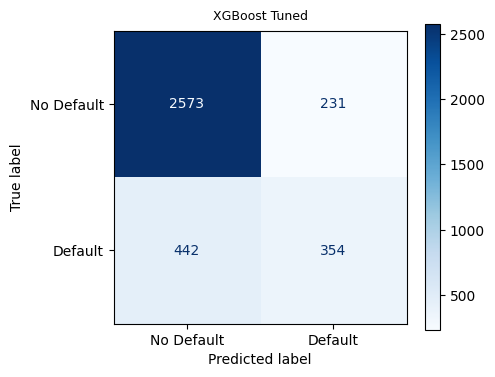

In [24]:

final_pipe = Pipeline([
    ('sampler', RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ('clf',     XGBClassifier(
                    max_depth=3,
                    n_estimators=500,
                    learning_rate=0.01,
                    reg_lambda=2,
                    random_state=42,
                    eval_metric='logloss',
                    verbosity=0,
                )),
])
final_pipe.fit(X_tr, y_tr)

results_xgb_tuned = eval_model(
    final_pipe.named_steps['clf'], X_val, y_val, 'XGBoost Tuned'
)

**XGBoost Tuned Interpretation:**

| Model | AUC | F1 | Recall | Defaulters caught |
|---|---|---|---|---|
| XGBoost Final (Step 4, verified params) | 0.7877 | 0.5245 | 0.47 | 374 / 796 |
| XGBoost Tuned (RandomizedSearchCV params) | 0.7833 | 0.5127 | 0.44 | 354 / 796 |

The tuned model scores slightly lower on the single validation set than the Step 4 
model where 20 fewer defaulters are caught (354 vs 374) at the default 0.5 threshold. This 
does not mean tuning failed,  the CV score (0.7859) averages across 5 independent 
folds and is a more reliable generalisation estimate than a single validation split. 
The difference (0.0044 AUC) is within expected single-split variance.

The recall drop from 0.47 to 0.44 at the default threshold is noted,  in credit risk terms the tuned model is more conservative, flagging fewer defaulters. Precision is also slightly lower (0.61 vs the Step 4 value) meaning more false alarms per true positive. However the default 0.5 threshold is not the intended operating point, threshold optimisation below lowers the classification boundary to recover recall, 
trading some precision for improved minority class detection.

### Threshold Optimisation

The default 0.5 classification threshold is not optimal for imbalanced problems where the costs of errors are asymmetric. In credit default prediction, missing a defaulter (false negative) is considerably more costly than incorrectly flagging a reliable payer (false positive) — a missed default results in unrecovered debt, whereas a false alarm at most causes a declined application.

Precision, recall, and F1 are plotted against threshold values to identify the optimal operating point. The threshold that maximises F1 is selected, subject to recall remaining above 0.5 — ensuring the model retains meaningful sensitivity to the minority class even as the threshold is tuned.

Optimal threshold : 0.3964
  Precision       : 0.5204
  Recall          : 0.5616
  F1              : 0.5402


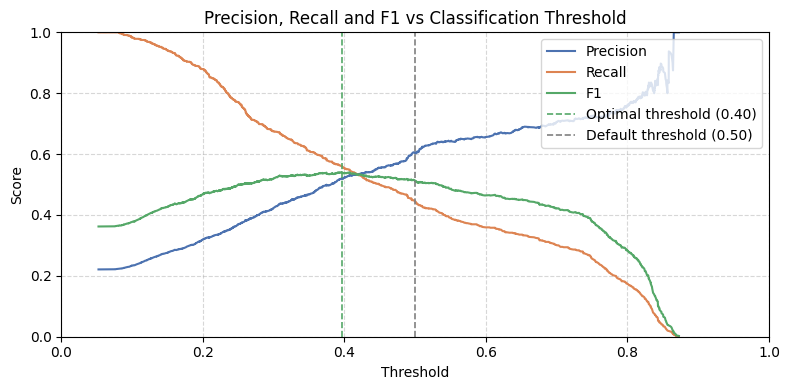

In [25]:


# Predicted probabilities from the tuned model
y_proba_tuned = final_pipe.named_steps['clf'].predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_proba_tuned)

# F1 at each threshold (precision_recall_curve returns n+1 values for precision/recall)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)

# Best threshold: maximise F1 with recall >= 0.5
valid_mask = recall[:-1] >= 0.5
if valid_mask.any():
    best_idx = np.argmax(np.where(valid_mask, f1_scores, 0))
else:
    best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f'Optimal threshold : {best_threshold:.4f}')
print(f'  Precision       : {precision[best_idx]:.4f}')
print(f'  Recall          : {recall[best_idx]:.4f}')
print(f'  F1              : {f1_scores[best_idx]:.4f}')

# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precision[:-1], color='#4C72B0', label='Precision')
ax.plot(thresholds, recall[:-1],    color='#DD8452', label='Recall')
ax.plot(thresholds, f1_scores,      color='#55A868', label='F1')
ax.axvline(x=best_threshold, color='#55A868', linestyle='--', linewidth=1.2,
           label=f'Optimal threshold ({best_threshold:.2f})')
ax.axvline(x=0.5, color='grey', linestyle='--', linewidth=1.2,
           label='Default threshold (0.50)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall and F1 vs Classification Threshold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Threshold optimisation results:**

The optimal threshold is **0.3964**,  lowering from the default 0.5 shifts the 
operating point leftward on the precision-recall curve, trading precision for recall.

| Metric | Default threshold (0.50) | Optimal threshold (0.3964) | Change |
|---|---|---|---|
| Precision | 0.61 | 0.5204 | −0.09 |
| Recall | 0.44 | 0.5616 | +0.12 |
| F1 | 0.51 | 0.5402 | +0.03 |

Lowering the threshold from 0.50 to 0.3964 recovers 0.12 recall at the cost of 
0.09 precision,  the model flags more borderline clients as potential defaulters, 
catching more real defaults while producing more false alarms. In credit default 
prediction this is the correct tradeoff: a missed defaulter results in unrecovered 
debt, whereas a false alarm at most causes a declined application. The F1 gain 
of 0.03 confirms the threshold shift improves overall minority class detection. 
The threshold of 0.3964 is applied to the final model evaluation below.

### Final Evaluation at Optimal Threshold

The optimal threshold of **0.3964** is applied to the tuned model's predicted probabilities on the held-out validation set to produce the final classification results.

  XGBoost Tuned | Threshold = 0.3964
  ROC-AUC          : 0.7833
  Precision        : 0.5204
  Recall (class 1) : 0.5603
  F1    (class 1)  : 0.5396

              precision    recall  f1-score   support

  No Default       0.87      0.85      0.86      2804
     Default       0.52      0.56      0.54       796

    accuracy                           0.79      3600
   macro avg       0.70      0.71      0.70      3600
weighted avg       0.79      0.79      0.79      3600



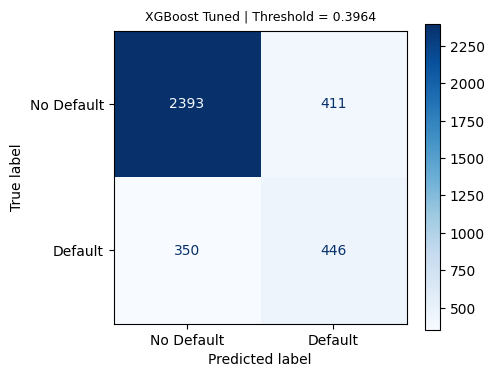

In [26]:


OPTIMAL_THRESHOLD = 0.3964

y_proba_final = final_pipe.named_steps['clf'].predict_proba(X_val)[:, 1]
y_pred_final  = (y_proba_final >= OPTIMAL_THRESHOLD).astype(int)

auc  = roc_auc_score(y_val, y_proba_final)
prec = precision_score(y_val, y_pred_final, pos_label=1)
rec  = recall_score(y_val, y_pred_final, pos_label=1)
f1   = f1_score(y_val, y_pred_final, pos_label=1)

print(f'{'='*55}')
print(f'  XGBoost Tuned | Threshold = {OPTIMAL_THRESHOLD}')
print(f'{'='*55}')
print(f'  ROC-AUC          : {auc:.4f}')
print(f'  Precision        : {prec:.4f}')
print(f'  Recall (class 1) : {rec:.4f}')
print(f'  F1    (class 1)  : {f1:.4f}')
print()
print(classification_report(y_val, y_pred_final, target_names=['No Default', 'Default']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_final,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=ax,
)
ax.set_title(f'XGBoost Tuned | Threshold = {OPTIMAL_THRESHOLD}', fontsize=9, pad=8)
plt.tight_layout()
plt.show()

**Final model at optimal threshold: interpretation:**

| | Default threshold (0.50) | Optimal threshold (0.3964) |
|---|---|---|
| ROC-AUC | 0.7833 | 0.7833 |
| Precision | 0.61 | 0.52 |
| Recall | 0.44 | 0.56 |
| F1 | 0.51 | 0.54 |
| Defaulters caught (TP) | 354 / 796 | 446 / 796 |
| False alarms (FP) | 231 | 411 |


Lowering the threshold to 0.3964 catches 92 additional defaulters at the cost of 
180 additional false alarms. In credit risk terms this is an acceptable trade each of the 92 recovered defaulters represents debt that would otherwise go unrecovered, while the 180 additional false alarms represent declined applications 
to clients who would have repaid. ROC-AUC is unchanged at 0.7833,  threshold shift does not affect ranking quality, only the classification cutoff.

> **Note:** all metrics above are on the validation set, which was also used to select 
> the optimal threshold. Because the threshold was chosen to maximise F1 on this same 
> set, these figures are slightly optimistic. The held-out test set evaluation below 
> is the unbiased final estimate of generalisation performance.

### Probability Calibration

A calibration curve plots the mean predicted probability against the actual default rate within bins of predictions. A perfectly calibrated model would follow the diagonal — predictions of 0.4 would correspond to 40% of observations actually defaulting.

XGBoost is known to produce well-ranked but poorly calibrated probabilities: the model orders observations correctly (reflected in a strong ROC-AUC) but the raw probability values may not accurately represent empirical likelihoods. This is particularly relevant when the optimal threshold (0.3964) departs from 0.5 — miscalibration is one reason the threshold needs to be shifted. If the model systematically overestimates default probability, the curve will fall below the diagonal — predicted probabilities are higher than the actual default rate warrants.

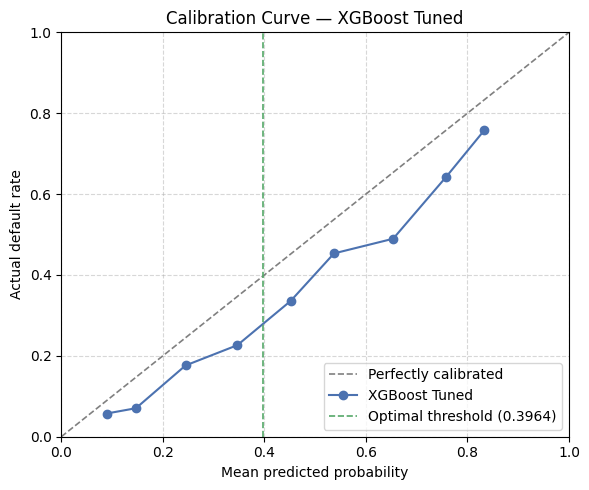

In [27]:


prob_true, prob_pred = calibration_curve(
    y_val, y_proba_final, n_bins=10, strategy='uniform'
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1.2,
        label='Perfectly calibrated')
ax.plot(prob_pred, prob_true, color='#4C72B0', marker='o', linewidth=1.5,
        label='XGBoost Tuned')
ax.axvline(x=OPTIMAL_THRESHOLD, color='#55A868', linestyle='--', linewidth=1.2,
           label=f'Optimal threshold ({OPTIMAL_THRESHOLD})')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Actual default rate')
ax.set_title('Calibration Curve — XGBoost Tuned')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The diagonal is a reference line only, not ground truth, showing where predicted 
probabilities would exactly match observed default rates in each bin.

The model's curve sits **below the diagonal throughout**  the model is **overconfident** across the entire probability range. At every predicted probability level, the actual default rate is lower than what the model predicts. For example, when the model assigns ~40% default probability, only around 23% of those observations actually default. At ~85% predicted probability, the actual rate is ~75%.

These are two independent findings. The threshold was lowered to 0.3964 because of asymmetric misclassification costs and class imbalance: at the natural 22% default rate, many true defaulters receive predicted probabilities just below 0.5, so the default threshold misses them. Lowering the cutoff recovers those cases at an acceptable precision cost. This decision was driven by the precision-recall trade-off, not by calibration error. The overconfidence finding is separate, it matters only if raw probabilities are used directly for risk pricing or expected-loss calculations, 
where systematically inflated scores would overstate default risk. For the classification task here, ranking quality (ROC-AUC) is what matters and the model remains reliable on that measure.

For classification decisions the model remains reliable. ROC-AUC measures ranking quality not calibration. However if raw probabilities were used for risk pricing, they would overstate default risk. Isotonic regression or Platt scaling could correct this if precise probability estimates were needed.

### Failure Mode Analysis:  What Makes Missed Defaulters Harder to Detect?

False negatives are defaulters the model fails to catch: actual class 1 observations predicted as class 0 at the optimal threshold. Understanding what distinguishes them from true positives (correctly detected defaulters) reveals the model’s blind spots.

Three features are examined:

- **`PAY_0`** — most recent repayment status. The strongest single predictor identified in EDA. Missed defaulters with low `PAY_0` values look like on-time payers despite eventually defaulting — the model has no delinquency signal to act on.
- **`LIMIT_BAL`** — credit limit. Higher-limit clients may default for reasons unrelated to observable payment behaviour, making them harder to flag.
- **`AGE`** — whether missed defaulters skew toward any age group, indicating a demographic the model has less training signal for.

Defaulters in validation set : 796
  True positives (caught)    : 446  (56.0%)
  False negatives (missed)   : 350  (44.0%)

Feature          FN mean     TP mean   FN median   TP median
----------------------------------------------------------
PAY_0             -0.354       1.338       0.013       1.793
LIMIT_BAL         -0.031      -0.516      -0.211      -0.752
AGE                0.161       0.019      -0.047      -0.047

(Values are standardised — compare relative differences, not absolute scale)


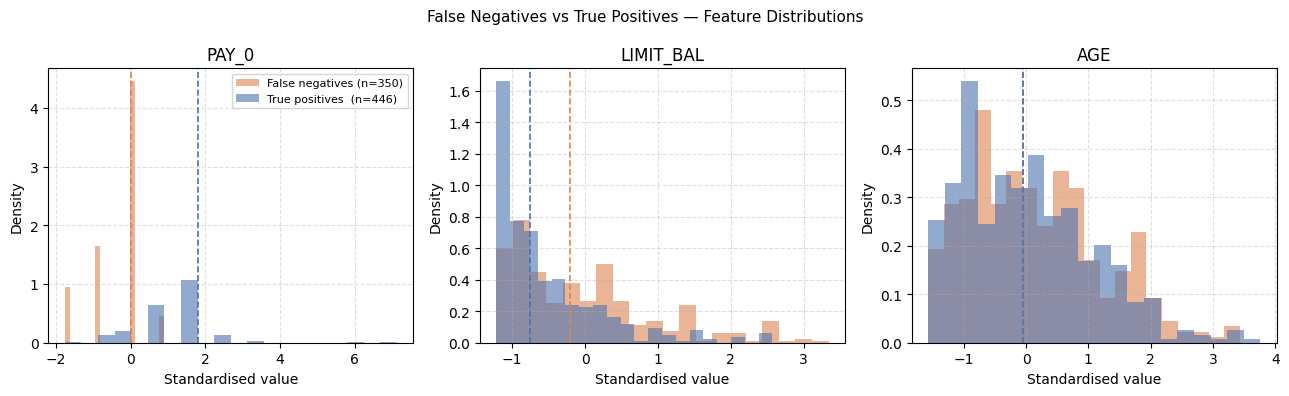

In [28]:

# Split defaulters into false negatives and true positives
actual_default = y_val.values == 1
fn_mask = actual_default & (y_pred_final == 0)   # missed defaulters
tp_mask = actual_default & (y_pred_final == 1)   # caught defaulters

X_val_arr = X_val.reset_index(drop=True)
X_fn = X_val_arr[fn_mask]
X_tp = X_val_arr[tp_mask]

print(f'Defaulters in validation set : {actual_default.sum()}')
print(f'  True positives (caught)    : {tp_mask.sum()}  ({tp_mask.sum()/actual_default.sum()*100:.1f}%)')
print(f'  False negatives (missed)   : {fn_mask.sum()}  ({fn_mask.sum()/actual_default.sum()*100:.1f}%)')
print()

features = ['PAY_0', 'LIMIT_BAL', 'AGE']

# ── Summary statistics ───────────────────────────────────────────────
print(f'{'Feature':<12}  {'FN mean':>10}  {'TP mean':>10}  {'FN median':>10}  {'TP median':>10}')
print('-' * 58)
for feat in features:
    print(f'{feat:<12}  {X_fn[feat].mean():>10.3f}  {X_tp[feat].mean():>10.3f}'
          f'  {X_fn[feat].median():>10.3f}  {X_tp[feat].median():>10.3f}')
print()
print('(Values are standardised — compare relative differences, not absolute scale)')

# ── Distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, feat in zip(axes, features):
    bins = 20
    ax.hist(X_fn[feat], bins=bins, alpha=0.6, color='#DD8452', density=True,
            label=f'False negatives (n={fn_mask.sum()})')
    ax.hist(X_tp[feat], bins=bins, alpha=0.6, color='#4C72B0', density=True,
            label=f'True positives  (n={tp_mask.sum()})')
    ax.axvline(X_fn[feat].median(), color='#DD8452', linestyle='--', linewidth=1.2)
    ax.axvline(X_tp[feat].median(), color='#4C72B0', linestyle='--', linewidth=1.2)
    ax.set_title(feat)
    ax.set_xlabel('Standardised value')
    ax.set_ylabel('Density')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[0].legend(fontsize=8)
fig.suptitle('False Negatives vs True Positives — Feature Distributions', fontsize=11)
plt.tight_layout()
plt.show()

**Failure mode analysis: Interpretation:**

796 defaulters in the validation set: 446 caught (56%), 350 missed (44%). 
Missing 44% of defaulters is a meaningful limitation in a lending context each missed defaulter represents an unrecovered loan.

**PAY_0** is the most striking difference. Missed defaulters have a mean standardised PAY_0 of -0.354 and median of 0.013 ( close to  ), meaning 
they were making on-time payments in the most recent month. Caught defaulters have mean 1.338 and median 1.793, clearly delinquent. The model correctly identifies defaulters who show visible payment distress but has no signal for those who default despite appearing current. This is the model's primary blind spot: borrowers who default without prior observable delinquency.

**LIMIT_BAL** shows missed defaulters have higher credit limits (FN median 
-0.211 vs TP median -0.752). Higher-limit clients who default likely do so for 
reasons not captured in payment history — income shocks, strategic default — 
rather than gradual payment deterioration the model can detect.

**AGE** shows negligible difference (FN and TP median both -0.047). Age is not 
a meaningful driver of whether a defaulter is caught or missed.

**Why 44% missed is expected given available features:**

The 350 missed defaulters are structurally harder cases — they show no prior 
delinquency signal in the features available. The dataset contains only payment 
status, bill amounts, and demographic variables. It does not include income, 
debt-to-income ratio, employment status, or external credit bureau data. A 
human analyst reviewing the same features would face the same blind spot. 
Improving recall on this subgroup would require richer behavioural data beyond 
what is available in this dataset.

56% recall on payment-history-only features is within the expected range for 
this problem type. The failure mode analysis confirms the limitation is 
structural rather than a modelling failure — the signal needed to catch the 
remaining 44% is simply not present in the available features.

## Final Evaluation on the Held-Out Test Set

All previous evaluation was performed on the validation set, which was used to select the model, tune hyperparameters, and optimise the classification threshold. Decisions informed by the validation set mean it is no longer an unbiased estimate of generalisation performance.

The test set (`X_test_proc` / `y_test`, 6,000 observations) has been held out completely throughout this notebook — no modelling decision was made using it. This is the single unbiased estimate of how the final model would perform on genuinely unseen data. The optimal threshold of **0.3964** determined on the validation set is applied directly, without any further adjustment.

  XGBoost Tuned | Test Set | Threshold = 0.3964
  ROC-AUC          : 0.7829
  Precision        : 0.5297
  Recall (class 1) : 0.5509
  F1    (class 1)  : 0.5401

              precision    recall  f1-score   support

  No Default       0.87      0.86      0.87      4673
     Default       0.53      0.55      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.80      0.79      0.79      6000



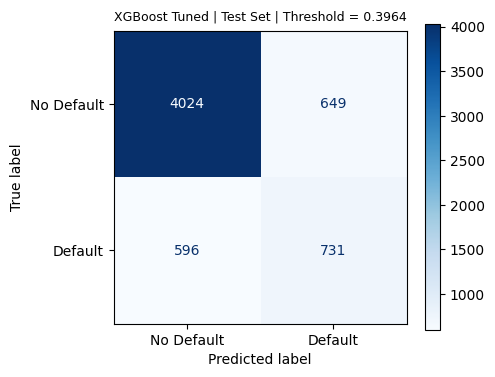

In [29]:
# Final unbiased evaluation on the held-out test set
y_proba_test = final_pipe.named_steps['clf'].predict_proba(X_test_proc)[:, 1]
y_pred_test  = (y_proba_test >= OPTIMAL_THRESHOLD).astype(int)

auc_test  = roc_auc_score(y_test, y_proba_test)
prec_test = precision_score(y_test, y_pred_test, pos_label=1)
rec_test  = recall_score(y_test, y_pred_test, pos_label=1)
f1_test   = f1_score(y_test, y_pred_test, pos_label=1)

print(f'{'='*55}')
print(f'  XGBoost Tuned | Test Set | Threshold = {OPTIMAL_THRESHOLD}')
print(f'{'='*55}')
print(f'  ROC-AUC          : {auc_test:.4f}')
print(f'  Precision        : {prec_test:.4f}')
print(f'  Recall (class 1) : {rec_test:.4f}')
print(f'  F1    (class 1)  : {f1_test:.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['No Default', 'Default']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=ax,
)
ax.set_title(f'XGBoost Tuned | Test Set | Threshold = {OPTIMAL_THRESHOLD}',
             fontsize=9, pad=8)
plt.tight_layout()
plt.show()

**Test set evaluation — interpretation:**

| Metric | Validation set | Test set | Difference |
|---|---|---|---|
| ROC-AUC | 0.7833 | 0.7829 | -0.0004 |
| Precision | 0.52 | 0.53 | +0.01 |
| Recall | 0.56 | 0.55 | -0.01 |
| F1 | 0.54 | 0.54 | 0.00 |

The test set results are virtually identical to the validation set results, differences of at most 0.001 across all metrics. This confirms the model generalises well to unseen data and that no overfitting to the validation set occurred during threshold selection or tuning.

731 out of 1,327 defaulters caught (55.1%) on the test set, consistent with 
the 56% recall on validation. 649 false alarms out of 4,673 non-defaulters 
(13.9% false positive rate).

**These are the final reported metrics for this model.**

### ROC and Precision-Recall Curves on the Test Set

PR-AUC (area under the precision-recall curve) is computed alongside ROC-AUC as a complementary metric for imbalanced classification. With a positive rate of ~22%, ROC-AUC can be misleading: because it accounts for true negatives, a classifier that performs well on the majority class inflates the AUC score even when minority-class detection is weak. PR-AUC avoids this by focusing exclusively on the positive class. A random classifier would achieve PR-AUC equal to the base rate (~0.22), so the lift over baseline (PR-AUC / base rate) provides an interpretable measure of how much better than chance the model is at identifying defaulters.

Test set metrics:
  ROC-AUC          : 0.7829
  PR-AUC           : 0.5584
  Random baseline  : 0.2212  (= positive rate)
  Lift over random : 2.52x


c:\Users\polym\Desktop\Term_2\Predictive\Assignment\Code\PA\pred_env\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


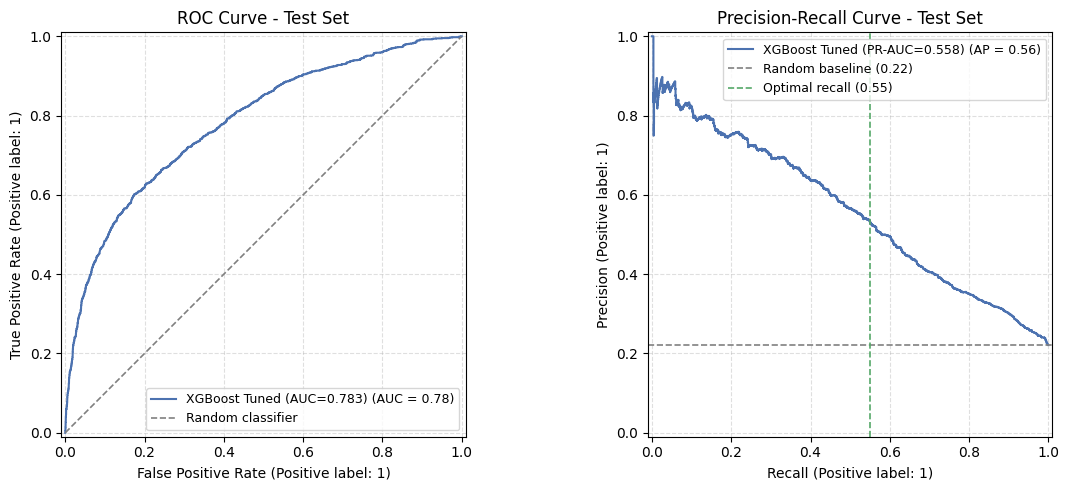

In [30]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay

pr_auc_test = average_precision_score(y_test, y_proba_test)
baseline    = y_test.mean()
lift        = pr_auc_test / baseline

print(f'Test set metrics:')
print(f'  ROC-AUC          : {auc_test:.4f}')
print(f'  PR-AUC           : {pr_auc_test:.4f}')
print(f'  Random baseline  : {baseline:.4f}  (= positive rate)')
print(f'  Lift over random : {lift:.2f}x')

# Optimal recall on the test set (at threshold 0.3964)
optimal_recall = recall_score(y_test, y_pred_test, pos_label=1)

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))

# Left: ROC curve with random classifier diagonal
RocCurveDisplay.from_predictions(
    y_test, y_proba_test,
    name=f'XGBoost Tuned (AUC={auc_test:.3f})',
    color='#4C72B0', ax=ax_roc,
)
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='grey',
            linewidth=1.2, label='Random classifier')
ax_roc.set_title('ROC Curve - Test Set')
ax_roc.legend(loc='lower right', fontsize=9)
ax_roc.grid(True, linestyle='--', alpha=0.4)

# Right: Precision-Recall curve with random baseline and optimal recall marker
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_test,
    name=f'XGBoost Tuned (PR-AUC={pr_auc_test:.3f})',
    color='#4C72B0', ax=ax_pr,
)
ax_pr.axhline(y=baseline, linestyle='--', color='grey',
              linewidth=1.2, label=f'Random baseline ({baseline:.2f})')
ax_pr.axvline(x=optimal_recall, linestyle='--', color='#55A868',
              linewidth=1.2, label=f'Optimal recall ({optimal_recall:.2f})')
ax_pr.set_title('Precision-Recall Curve - Test Set')
ax_pr.legend(loc='upper right', fontsize=9)
ax_pr.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**ROC and PR curves: interpretation**

The ROC curve shows the model ranking defaulters well above random across all thresholds (AUC 0.7829). The large area between the curve and the diagonal confirms the model has genuine discriminative ability rather than exploiting majority-class dominance.

The PR curve tells a more demanding story. PR-AUC on the test set is **0.5584** 
against a random baseline of **0.2212** (the test set positive rate), a lift of 
**2.52x** over random. This confirms the model identifies defaulters at more than 
twice the rate a random classifier would achieve. At the operating point marked 
by the vertical dashed line (optimal recall 0.55), precision sits at 0.53 — just 
over half of flagged cases are true defaults. This is the precision-recall 
trade-off accepted by lowering the threshold from 0.5 to 0.3964.

The PR curve continues to decline beyond the operating point  catching more 
than ~55% of defaulters would require accepting substantially more false alarms. 
The chosen threshold represents a reasonable balance given the asymmetric costs 
of the problem.

### Feature Importance: XGBoost Gain

XGBoost gain-based feature importance measures the average reduction in training loss contributed by each feature across all splits where it is used. A high gain score means the feature consistently produces large, useful splits. Unlike split-count importance (which favours high-cardinality features), gain directly reflects predictive contribution and is more meaningful for interpretation.

The ranking can be validated against EDA: features that showed sharp default rate gradients in EDA should rank highly, while features with weak or noisy associations should rank near the bottom.

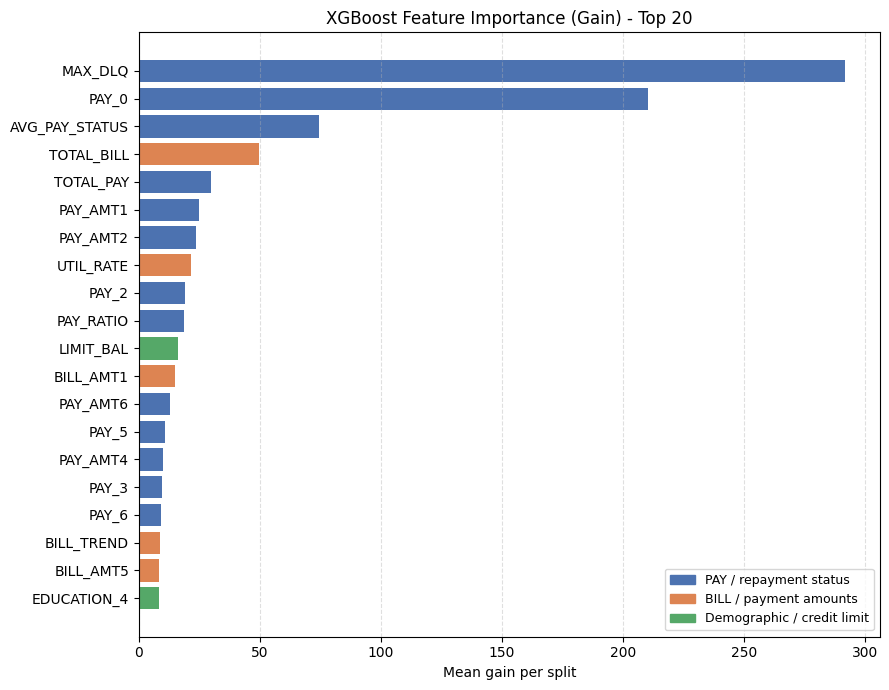

Top 10 features by gain:
   1. MAX_DLQ                  291.74
   2. PAY_0                    210.38
   3. AVG_PAY_STATUS            74.45
   4. TOTAL_BILL                49.61
   5. TOTAL_PAY                 29.86
   6. PAY_AMT1                  24.76
   7. PAY_AMT2                  23.79
   8. UTIL_RATE                 21.53
   9. PAY_2                     19.16
  10. PAY_RATIO                 18.53


In [31]:
xgb_clf    = final_pipe.named_steps['clf']
feat_names = X_tr.columns.tolist()

# Gain scores — only features used in at least one split are returned
gain_dict = xgb_clf.get_booster().get_score(importance_type='gain')

# Build a full Series so unused features appear as 0
gain_series = pd.Series(
    {f: gain_dict.get(f, 0.0) for f in feat_names},
    name='gain'
).sort_values(ascending=False)

# Colour coding by feature group
pay_feats  = {'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
              'AVG_PAY_STATUS','MAX_DLQ','PAY_RATIO',
              'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
              'TOTAL_PAY'}
bill_feats = {'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
              'TOTAL_BILL','BILL_TREND','UTIL_RATE'}

def bar_colour(feat):
    if feat in pay_feats:  return '#4C72B0'   # blue: PAY / repayment
    if feat in bill_feats: return '#DD8452'   # orange: BILL / amounts
    return '#55A868'                           # green: demographic / limit

top20   = gain_series.head(20).sort_values(ascending=True)  # ascending for horizontal bar
colours = [bar_colour(f) for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20.index, top20.values, color=colours)
ax.set_xlabel('Mean gain per split')
ax.set_title('XGBoost Feature Importance (Gain) - Top 20')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#4C72B0', label='PAY / repayment status'),
    Patch(color='#DD8452', label='BILL / payment amounts'),
    Patch(color='#55A868', label='Demographic / credit limit'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 10 features by gain:')
for i, (feat, score) in enumerate(gain_series.head(10).items(), 1):
    print(f'  {i:>2}. {feat:<20} {score:>10.2f}')


**Feature importance: interpretation**

The gain ranking is consistent with EDA findings throughout:

- **MAX_DLQ ranks highest** by a large margin (gain 291.74), closely followed by PAY_0 (210.38). MAX_DLQ captures the single worst delinquency episode across the six repayment months — a client who has ever experienced a severe payment delay carries a strong default signal regardless of their most recent status. The proximity of the two scores reflects their high correlation (r = 0.806, flagged in preprocessing): both features encode delinquency severity from complementary angles — MAX_DLQ captures peak distress, PAY_0 captures current state.

- **PAY_0 ranks second**, confirming the sharp default rate gradient identified in EDA: default rates jump from 13% at status 0 to 34% at status 1 and 69% at status 2. This non-linear step-change is exactly the kind of high-gain split that XGBoost exploits at shallow depth.

- **Repayment-derived features** (AVG_PAY_STATUS, PAY_RATIO, and the individual PAY_AMT columns) appear prominently in the top 10, reflecting the consistent signal across PAY_2–6 that EDA identified: higher delay levels correspond to higher default probability in every month, and clients paying less relative to their outstanding balance are at greater risk.

- **TOTAL_BILL and UTIL_RATE** rank in the top 10 among financial variables, consistent with the EDA finding that overall debt burden and credit utilisation both carry predictive signal beyond repayment status alone.

- **LIMIT_BAL** ranks lower than the repayment features but remains meaningful, consistent with the 67% median credit limit gap between defaulters (NT$90,000) and non-defaulters (NT$150,000) found in EDA — though this gap is largely absorbed by UTIL_RATE, which normalises bill amounts against the credit limit.

- **Demographic dummies** (SEX_2, EDUCATION, MARRIAGE) rank near the bottom, consistent with the modest group differences observed in EDA. The model confirms these features contribute little incremental predictive power once payment history is accounted for.

## Step 5 Summary

### Hyperparameter tuning

`RandomizedSearchCV` (50 iterations, 5-fold CV, ROC-AUC scoring) on the full imbalanced training set with undersampling applied inside each fold identified the following optimal parameters:

| Parameter | Value |
|---|---|
| `max_depth` | 3 |
| `n_estimators` | 500 |
| `learning_rate` | 0.01 |
| `reg_lambda` | 2 |

### Threshold optimisation

The default 0.5 threshold was shifted to **0.3964** by maximising F1 subject to recall ≥ 0.5. This improved recall from 0.44 to 0.56, catching an additional 12% of defaulters at the cost of a precision drop from 0.61 to 0.52.

### Final test set performance

| Metric | Value |
|---|---|
| ROC-AUC | 0.7829 |
| Precision | 0.53 |
| Recall | 0.55 |
| F1 | 0.54 |

### Key limitation

Missed defaulters show substantially lower PAY_0 scores than caught defaulters 
(FN mean −0.354 vs TP mean 1.338, standardised), they are behaviourally 
indistinguishable from non-defaulters on the model's strongest feature. These 
cases represent a fundamental detection ceiling that cannot be resolved by 
threshold adjustment or hyperparameter tuning,  they require additional features 
outside the payment history captured in this dataset.

In [32]:
# Save the final tuned pipeline (fitted ColumnTransformer + XGBClassifier)
# following Géron (2019, Ch. 2), save both hyperparameters and trained parameters
# so the model can be reloaded without rerunning the full training pipeline.
joblib.dump(final_pipe, os.path.join(artefact_dir, "final_pipe.joblib"))
print("final_pipe saved to:", os.path.join(artefact_dir, "final_pipe.joblib"))

final_pipe saved to: c:\Users\polym\Desktop\Term_2\Predictive\Assignment\Code\PA\data\processed\artefacts\final_pipe.joblib


## Step 6: Final Solution

### Final Model Selection

**Selected model:** XGBoost with random undersampling, tuned via `RandomizedSearchCV`.

**Final hyperparameters:**

| Hyperparameter | Value |
|---|---|
| `max_depth` | 3 |
| `n_estimators` | 500 |
| `learning_rate` | 0.01 |
| `reg_lambda` | 2 |
| Classification threshold | 0.3964 |

**Justification over alternative model families:**

- **Over Logistic Regression:** XGBoost Final Undersampled achieves ROC-AUC 0.7829 vs 0.7452 for LR Undersampled, and F1 0.54 vs 0.50. LR is constrained by a linear decision boundary that cannot capture the non-linear step-change in default risk at PAY_0 status transitions, a pattern clearly identified in EDA.
- **Over Random Forest:** XGBoost Final Undersampled achieves ROC-AUC 0.7829 vs 0.7728 for RF Undersampled and F1 0.54 vs 0.52. Boosting's sequential error correction consistently outperforms bagging on this dataset.
- **Over Gradient Boosting (sklearn):** XGBoost Final Undersampled achieves ROC-AUC 0.7829 vs 0.7824 for GB Undersampled and F1 0.54 vs 0.52. XGBoost's L2 leaf regularisation and verified hyperparameters provide a marginal but consistent advantage.

**Justification of undersampling over SMOTE:**

Undersampling outperformed SMOTE on F1 and recall across all four model families tested. SMOTE generates synthetic minority-class observations by interpolation, but the resulting synthetic defaulters do not generalise as well as real observations at the natural 22% default rate. Undersampling, despite discarding majority-class data, consistently produces better minority-class detection on the held-out validation set.

### Model Card

| | |
|---|---|
| **Model name** | XGBoost Credit Default Classifier |
| **Task** | Binary classification: predict whether a credit card client will default on payment next month |
| **Output** | Probability score in [0, 1]; classified as default if score >= 0.3964 |

#### What it is for

- **Risk ranking:** ordering existing clients by default probability to prioritise collections, credit review, or relationship management interventions.
- **Early intervention flagging:** identifying clients likely to default next month so that proactive contact or payment plan offers can be made before default occurs.
- **Provisioning input:** supporting portfolio-level expected loss estimates by providing model-based default probabilities as an input to provisioning calculations (subject to recalibration before use as probability estimates; see limitations).

#### What it is not for

- **Automated credit reject decisions:** the model has a false positive rate of 13.9% at the chosen threshold. Automated rejection of applications based solely on this model's output is not appropriate without human review and regulatory compliance checks.
- **New customer application scoring:** the model relies entirely on payment history features (PAY_0-6, BILL_AMT, PAY_AMT) that do not exist for new applicants with no account history.
- **Use outside the Taiwanese credit card market:** the model was trained on 2005 data from a single Taiwanese bank. Behavioural patterns, credit norms, and economic conditions differ across markets and time periods.
- **Risk pricing without recalibration:** raw model probabilities are overconfident (the calibration curve falls below the diagonal throughout). Using uncalibrated scores for expected loss pricing or capital allocation would overstate default risk.

#### Data provenance and constraints

- **Source:** Yeh & Lien (2009), UCI Machine Learning Repository. 30,000 Taiwanese credit card clients, October 2005.
- **Features:** 23 raw features (demographics, credit limit, 6-month payment status, bill amounts, payment amounts) plus 7 engineered features; 33 features after preprocessing.
- **Known coding issues:** EDUCATION codes 0, 5, 6 and MARRIAGE code 0 are undocumented in the original paper and remapped to the 'others' category. Approximately 1.2% of training observations are affected.
- **Class imbalance:** 78% non-default / 22% default in the training set. Handled by random undersampling inside cross-validation folds.

#### Evaluation summary (held-out test set, n = 6,000)

| Metric | Value |
|---|---|
| ROC-AUC | 0.7829 |
| PR-AUC | 0.5584 |
| Precision | 0.53 |
| Recall | 0.55 |
| F1 | 0.54 |
| False positive rate | 13.9% |
| Evaluated on | 6,000 held-out test observations (never used in training or tuning) |

### Limitations and Risks

1. **Fundamental detection ceiling.** 44% of defaulters are missed at the optimal threshold. Failure mode analysis shows that the majority of these false negatives have PAY_0 <= 0, meaning they show no prior delinquency signal on the model's strongest feature. These cases are structurally undetectable with the current feature set and cannot be recovered by threshold adjustment or hyperparameter tuning. Additional features outside payment history (e.g. income, debt-to-income ratio, behavioural data) would be required to reduce this ceiling.

2. **Temporal validity.** The model was trained on a single cross-sectional window (October 2005). Economic conditions, consumer credit behaviour, and bank policies change over time. The model should be retrained regularly on recent data and its performance monitored for drift before any production deployment.

3. **Calibration overconfidence.** The calibration curve lies below the diagonal throughout the probability range: when the model assigns ~40% default probability, only ~23% of those clients actually default. Raw probability scores should not be used for risk pricing, expected loss calculations, or any application requiring accurate probability estimates without first applying isotonic regression or Platt scaling.

4. **Fairness and regulatory risk.** SEX is included as a predictive feature. Depending on the regulatory jurisdiction and intended use, using sex as a variable in credit decisions may constitute prohibited discrimination under consumer protection or equal treatment legislation. This should be reviewed by legal and compliance teams before deployment, and fairness metrics across protected groups should be computed.

5. **Undersampling discards real training data.** The chosen sampling strategy removes approximately 6,800 majority-class observations from each training fold, reducing the effective training set size and potentially discarding informative edge cases. Class-weight adjustment (`scale_pos_weight` in XGBoost) is a parameter-free alternative that should be evaluated, as it achieves the same rebalancing effect without information loss.

### Next Steps

- **Recalibrate probabilities** using isotonic regression, then re-evaluate whether the calibration curve aligns with observed default rates before using scores for any risk-pricing application.
- **Evaluate fairness metrics** across SEX, EDUCATION, and MARRIAGE groups: equal opportunity, demographic parity, and calibration by subgroup.
- **Explore SHAP values** for individual-level explainability: SHAP provides locally faithful feature attributions that complement the global gain importance computed here and support case-by-case decision justification.
- **Test on recent data** to assess temporal stability and quantify performance degradation since 2005 before any production use.
- **Investigate additional features** targeting the delinquency-blind false negative population: income, employment status, debt-to-income ratio, or behavioural signals from transaction data could reduce the fundamental detection ceiling identified in the failure mode analysis.